<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/4_Flavour_oscillation(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 13.26 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src/NuOscProbExact/src/NuOscProbExact/src
globaldefs.py       hamiltonians3nu.py  oscprob3nu.py
hamiltonians2nu.py  oscprob2nu.py


In [71]:
import sys
sys.path.append('./NuOscProbExact/src')  # Add the src directory to your path if not already there.
import oscprob3nu


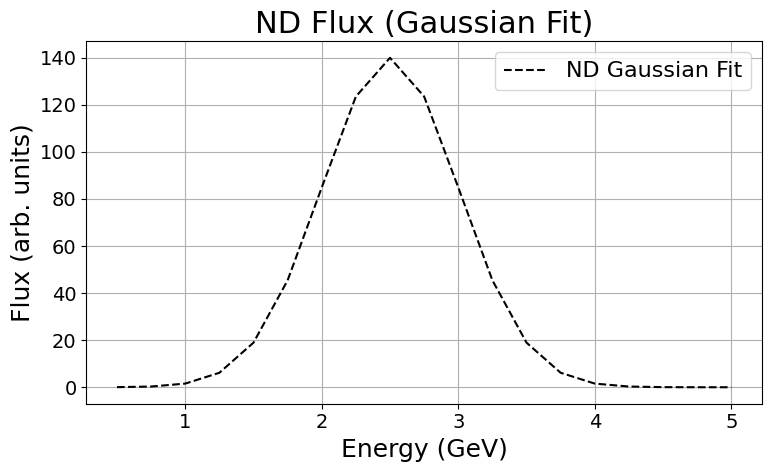

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import hamiltonians3nu
from globaldefs import S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
import matplotlib as mpl

mpl.rcParams.update({
    "figure.figsize":   (10, 6),
    "font.size":        16,
    "axes.titlesize":   22,
    "axes.labelsize":   18,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  16,
    "grid.linewidth":   0.8
})

# Global conversion constants (these should match your globaldefs)
CONV_KM_TO_INV_EV = 5.067731e9    # Converts km to inverse eV
VCC_EARTH_CRUST   = 7.6e-14       # Matter potential, e.g., from Earth's crust

# Standard three-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                     # CP phase (set to 0; modify to test CP variations)
D21     = 7.39e-5               # eV^2 (solar)
D31     = 2.525e-3              # eV^2 (atmospheric)

# Additional four-flavor parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0                     # Extra CP phase for sterile part
D41     = 1.0                   # eV^2 (sterile)

# Near Detector (ND) flux parameters
# For example, these popt_nd are obtained by fitting the ND data to a Gaussian:
popt_nd = [140, 2.5e9, 0.5e9]    # [Amplitude, Mean (eV), Sigma (eV)]
# Define energy bin centers and edges for ND flux (in eV)
bin_centers = np.linspace(0.5e9, 5e9, 19)  # 0.5 to 5 GeV in eV
bin_edges   = np.linspace(0.5e9, 5e9, 20)

# Define the Gaussian function used for the ND flux fit:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# (Optionally, you can plot the ND flux to verify)
plt.figure(figsize=(8,5))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Gaussian Fit")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("ND Flux (Gaussian Fit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Define the FD baseline (Far Detector at 810 km)
Length_far = 810

# Define the energy range used for FD spectrum plots (in GeV and convert to eV)
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9


In [73]:
def probability_3nu(E, L, transition='mm', matter=False):
    # Obtain energy-independent Hamiltonian for three-flavor oscillations
    h_vacuum_energy_indep = np.array(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF))
    # Full vacuum Hamiltonian: multiply by 1/E
    H = (1.0 / E) * h_vacuum_energy_indep
    if matter:
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, VCC_EARTH_CRUST)
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    # For an initial muon neutrino, the ordering in oscprob3nu.probabilities_3nu is:
    # [Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt]
    if transition == 'mm':
        return S[1, 1].real**2 + S[1, 1].imag**2
    elif transition == 'me':
        return S[1, 0].real**2 + S[1, 0].imag**2
    elif transition == 'mt':
        return S[1, 2].real**2 + S[1, 2].imag**2

# Four-flavor functions:
# These are assumed to be defined by your collaboration; if not, use the definitions provided earlier.
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13), c12*c23 - s12*s13*s23*np.exp(1j*delta13), c13*s23, s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13), -c12*s23 - s12*s13*c23*np.exp(1j*delta13), c13*c23, c24*s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                            delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    return H_vac + np.diag([VCC, 0, 0, 0])

def probability_4nu(energy, L, transition='mm', case='vacuum'):
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2
    elif transition == 'ms':
        return np.abs(S[1, 3])**2

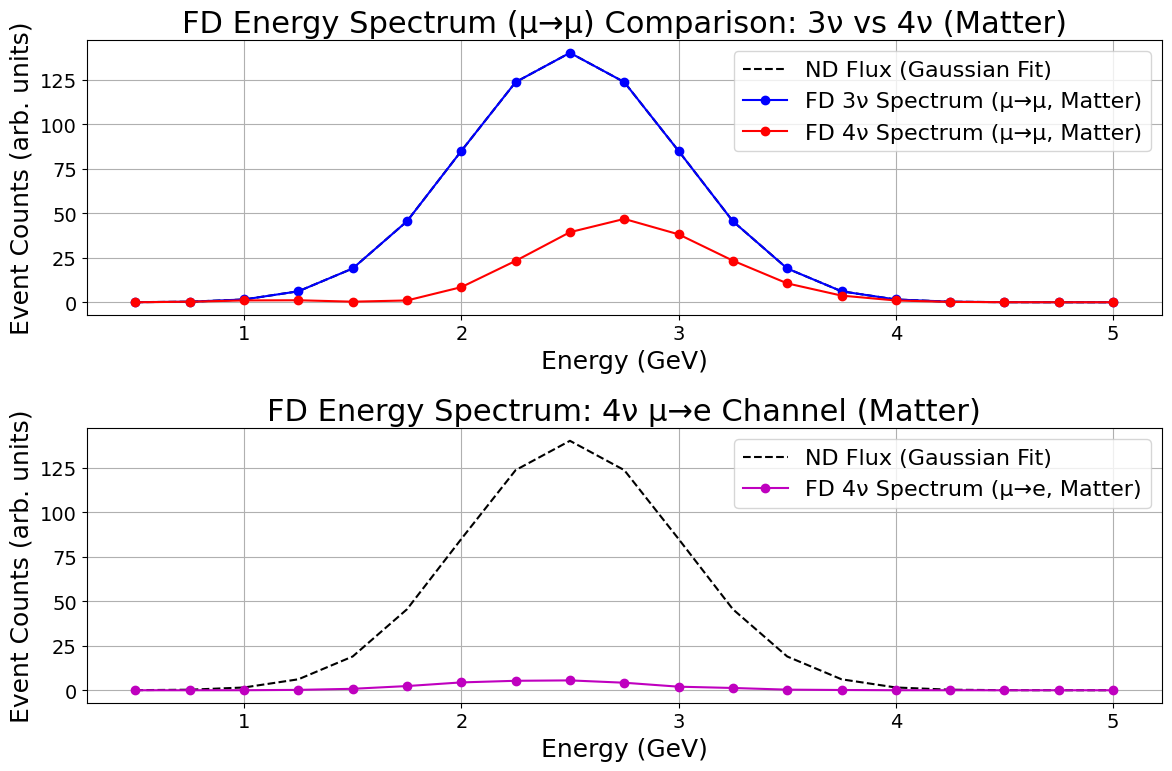

In [74]:
# FD Spectrum: for each energy bin, the event count is ND flux (Gaussian) * oscillation probability.
# FD spectrum using the three-flavor (matter) model (muon survival channel)
fd_spec_3nu = np.array([gaussian(E, *popt_nd) * probability_3nu(E, Length_far, transition='mm', matter=True)
                          for E in bin_centers])

# FD spectrum using the four-flavor (matter) model (muon survival channel)
fd_spec_4nu = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition='mm', case='matter')
                          for E in bin_centers])

# FD spectrum using the four-flavor (matter) model for the μ→e channel
fd_spec_4nu_me = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition='me', case='matter')
                             for E in bin_centers])

plt.figure(figsize=(12,8))

# Panel 1: Compare 3ν and 4ν (μ→μ) FD spectra.
plt.subplot(2,1,1)
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux (Gaussian Fit)")
plt.plot(bin_centers/1e9, fd_spec_3nu, 'b-o', label="FD 3ν Spectrum (μ→μ, Matter)")
plt.plot(bin_centers/1e9, fd_spec_4nu, 'r-o', label="FD 4ν Spectrum (μ→μ, Matter)")
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts (arb. units)")
plt.title("FD Energy Spectrum (μ→μ) Comparison: 3ν vs 4ν (Matter)")
plt.legend()
plt.grid(True)

# Panel 2: FD Energy Spectrum for 4ν μ→e channel.
plt.subplot(2,1,2)
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux (Gaussian Fit)")
plt.plot(bin_centers/1e9, fd_spec_4nu_me, 'm-o', label="FD 4ν Spectrum (μ→e, Matter)")
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts (arb. units)")
plt.title("FD Energy Spectrum: 4ν μ→e Channel (Matter)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

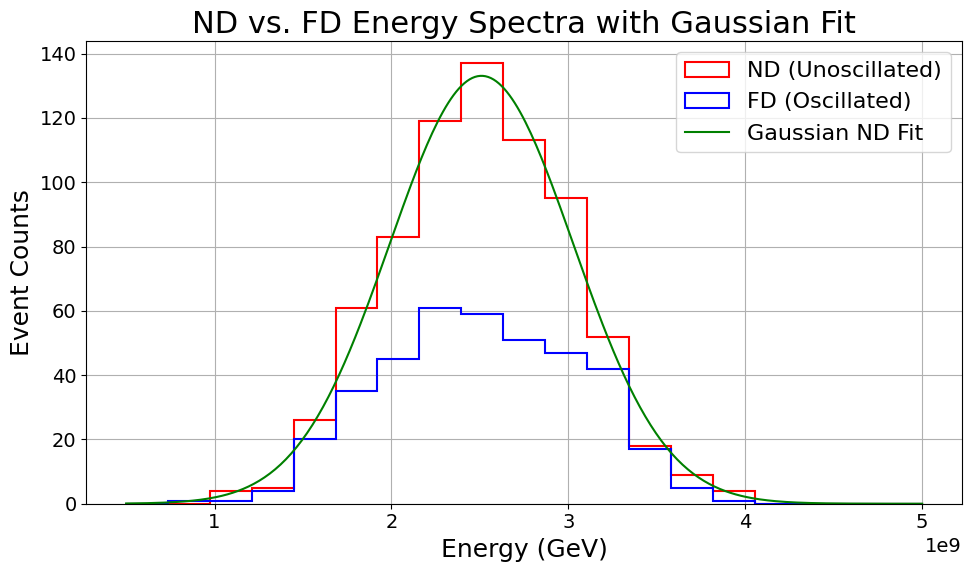

In [75]:
from scipy.optimize import curve_fit
from scipy.linalg import expm

bin_edges = np.linspace(0.5e9, 5e9, 20)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])  # midpoints for plotting

def dummy_gaussian_nd(E, A=140, mu=2.5e9, sigma=0.5e9):
    return A * np.exp(-0.5 * ((E - mu)/sigma)**2)

ND_counts = dummy_gaussian_nd(bin_centers)

ND_counts = np.random.poisson(ND_counts).astype(float)

def gaus(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2*sigma**2))

# curve_fit wants x, y
popt_nd, _ = curve_fit(
    gaus,
    bin_centers,
    ND_counts,
    p0=[np.max(ND_counts), 2.5e9, 0.5e9]
)

def probability_4nu_dummy(E):
    return 0.8 - 0.4 * np.exp(-0.5 * ((E - 2.5e9)/0.6e9)**2)

FD_counts = []
for bc in bin_centers:
    # Probability at this bin energy
    prob = probability_4nu_dummy(bc)
    # “Oscillated” FD counts = ND_counts * prob
    FD_counts.append(prob * dummy_gaussian_nd(bc))

FD_counts = np.array(FD_counts)
# Optionally Poisson fluctuate:
FD_counts = np.random.poisson(FD_counts).astype(float)

plt.figure(figsize=(10,6))

# ND histogram
plt.hist(
    bin_edges[:-1],
    bins=bin_edges,
    weights=ND_counts,
    histtype='step',
    color='red',
    linewidth=1.5,
    label='ND (Unoscillated)'
)

# FD histogram
plt.hist(
    bin_edges[:-1],
    bins=bin_edges,
    weights=FD_counts,
    histtype='step',
    color='blue',
    linewidth=1.5,
    label='FD (Oscillated)'
)

# Overplot the fitted Gaussian line for ND
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 300)
y_fit = gaus(x_fit, *popt_nd)
plt.plot(x_fit, y_fit, 'g-', label='Gaussian ND Fit')

plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts")
plt.title("ND vs. FD Energy Spectra with Gaussian Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [76]:
# Instead of 'probability_4nu_dummy':

def probability_4nu_dummy(E):
    return probability_4nu(E, 810, transition='mm', case='matter')

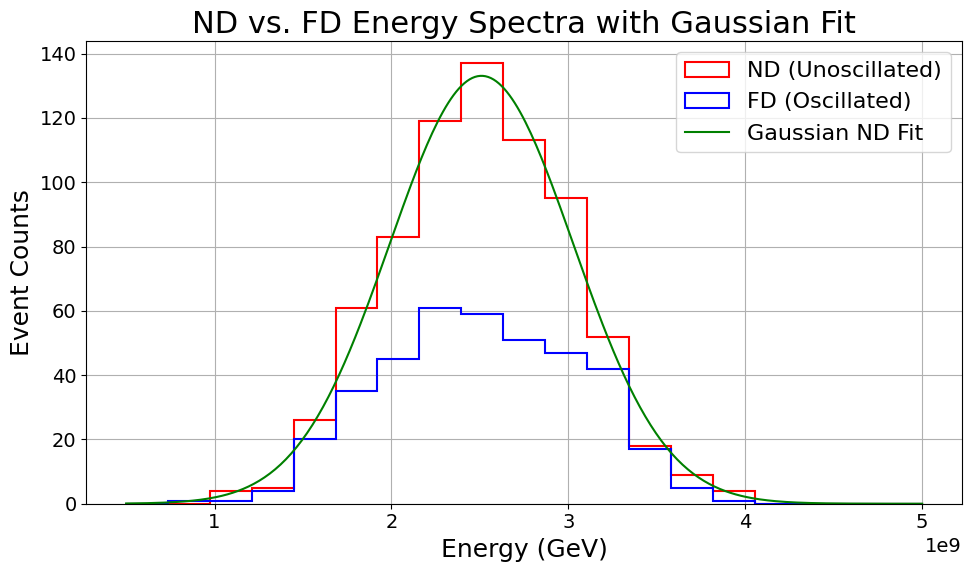

In [77]:
# ND histogram
plt.hist(
    bin_edges[:-1],
    bins=bin_edges,
    weights=ND_counts,
    histtype='step',
    color='red',
    linewidth=1.5,
    label='ND (Unoscillated)'
)

# FD histogram
plt.hist(
    bin_edges[:-1],
    bins=bin_edges,
    weights=FD_counts,
    histtype='step',
    color='blue',
    linewidth=1.5,
    label='FD (Oscillated)'
)

# Overplot the fitted Gaussian line for ND
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 300)
y_fit = gaus(x_fit, *popt_nd)
plt.plot(x_fit, y_fit, 'g-', label='Gaussian ND Fit')

plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts")
plt.title("ND vs. FD Energy Spectra with Gaussian Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

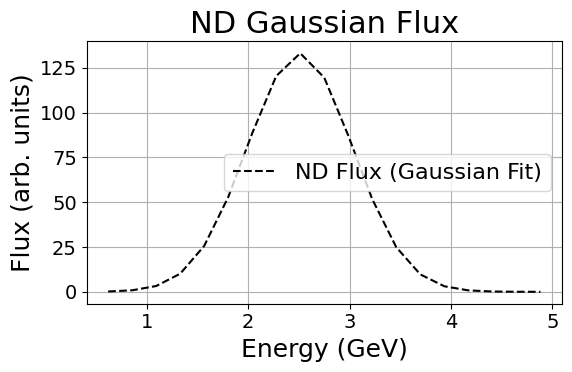

In [78]:
plt.figure(figsize=(6,4))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux (Gaussian Fit)")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("ND Gaussian Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
import oscprob3nu
import hamiltonians3nu
from globaldefs import S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF

def probability_3nu(E, L, transition='mm', matter=False):
    # Obtain energy-independent Hamiltonian for 3ν oscillations
    h0 = np.array(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF))
    H = (1.0 / E) * h0
    if matter:
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, VCC_EARTH_CRUST)
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    # In oscprob3nu, probabilities are returned in the order:
    # [Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt]
    if transition == 'mm':
        return (S[1,1].real**2 + S[1,1].imag**2)
    elif transition == 'me':
        return (S[1,0].real**2 + S[1,0].imag**2)
    elif transition == 'mt':
        return (S[1,2].real**2 + S[1,2].imag**2)

def probability_3nu_antinue(E, L, transition='mm', matter=False):
    # For anti-neutrinos, reverse sign of VCC in matter
    h0 = np.array(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF))
    H = (1.0 / E) * h0
    if matter:
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, -VCC_EARTH_CRUST)
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return (S[1,1].real**2 + S[1,1].imag**2)
    elif transition == 'me':
        return (S[1,0].real**2 + S[1,0].imag**2)
    elif transition == 'mt':
        return (S[1,2].real**2 + S[1,2].imag**2)


In [80]:
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13), c12*c23 - s12*s13*s23*np.exp(1j*delta13), c13*s23, s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13), -c12*s23 - s12*s13*c23*np.exp(1j*delta13), c13*c23, c24*s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                            delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    return H_vac + np.diag([VCC, 0, 0, 0])

def probability_4nu(energy, L, transition='mm', case='vacuum'):
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1,1])**2
    elif transition == 'me':
        return np.abs(S[1,0])**2
    elif transition == 'mt':
        return np.abs(S[1,2])**2
    elif transition == 'ms':
        return np.abs(S[1,3])**2

def probability_4nu_antinue(energy, L, transition='mm', case='vacuum'):
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        H = hamiltonian_4nu_matter(H_vac, energy, -VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1,1])**2
    elif transition == 'me':
        return np.abs(S[1,0])**2
    elif transition == 'mt':
        return np.abs(S[1,2])**2


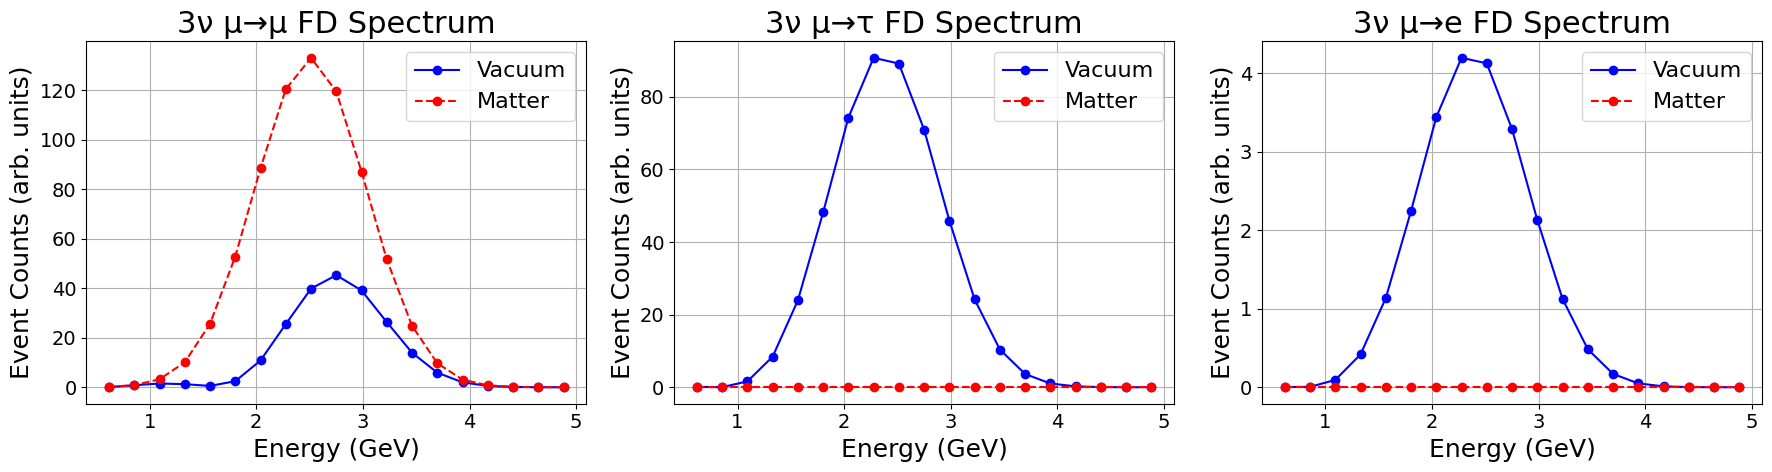

In [81]:
# For each transition in ['mm', 'mt', 'me'], compute FD spectrum as ND flux * oscillation probability.
plt.figure(figsize=(18,5))
transitions = ['mm','mt','me']
titles = {'mm':'μ→μ', 'mt':'μ→τ', 'me':'μ→e'}

for i, trans in enumerate(transitions):
    # Compute FD spectrum for vacuum and matter cases (using FD baseline)
    vacuum_spec = np.array([gaussian(E, *popt_nd) * probability_3nu(E, Length_far, transition=trans, matter=False)
                              for E in bin_centers])
    matter_spec = np.array([gaussian(E, *popt_nd) * probability_3nu(E, Length_far, transition=trans, matter=True)
                              for E in bin_centers])
    ax = plt.subplot(1,3,i+1)
    ax.plot(bin_centers/1e9, vacuum_spec, 'b-o', label='Vacuum')
    ax.plot(bin_centers/1e9, matter_spec, 'r--o', label='Matter')
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel("Event Counts (arb. units)")
    ax.set_title("3ν " + titles[trans] + " FD Spectrum")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


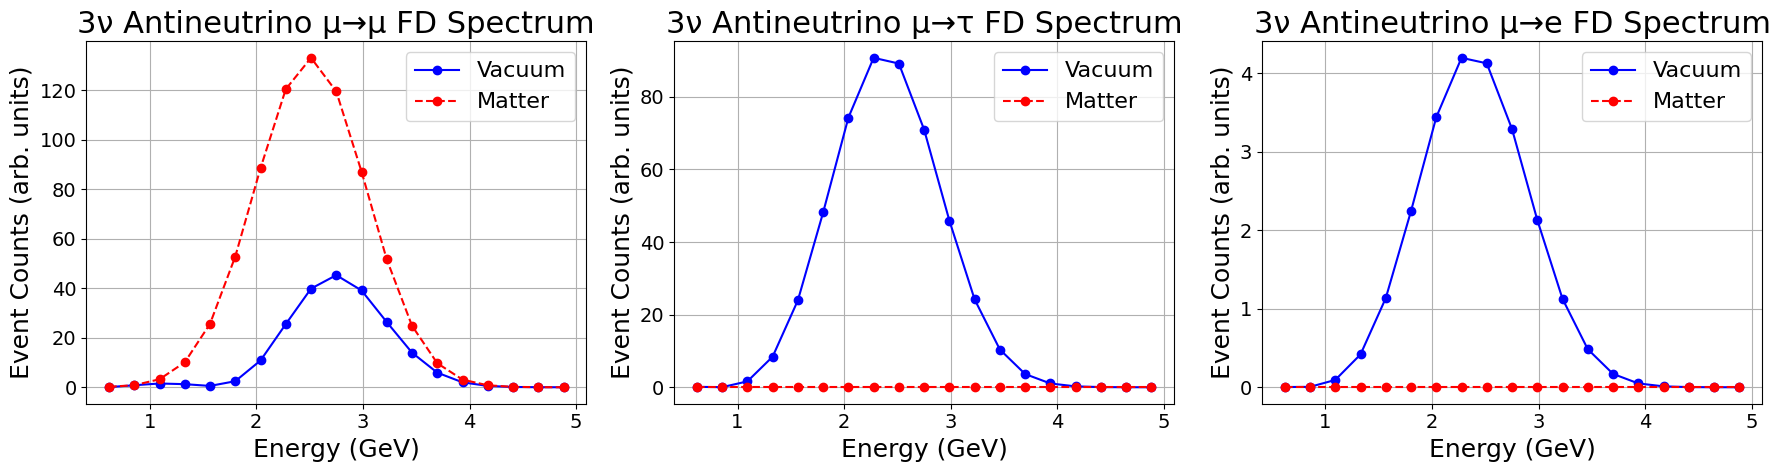

In [82]:
plt.figure(figsize=(18,5))
for i, trans in enumerate(transitions):
    vacuum_spec = np.array([gaussian(E, *popt_nd) * probability_3nu_antinue(E, Length_far, transition=trans, matter=False)
                              for E in bin_centers])
    matter_spec = np.array([gaussian(E, *popt_nd) * probability_3nu_antinue(E, Length_far, transition=trans, matter=True)
                              for E in bin_centers])
    ax = plt.subplot(1,3,i+1)
    ax.plot(bin_centers/1e9, vacuum_spec, 'b-o', label='Vacuum')
    ax.plot(bin_centers/1e9, matter_spec, 'r--o', label='Matter')
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel("Event Counts (arb. units)")
    ax.set_title("3ν Antineutrino " + titles[trans] + " FD Spectrum")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


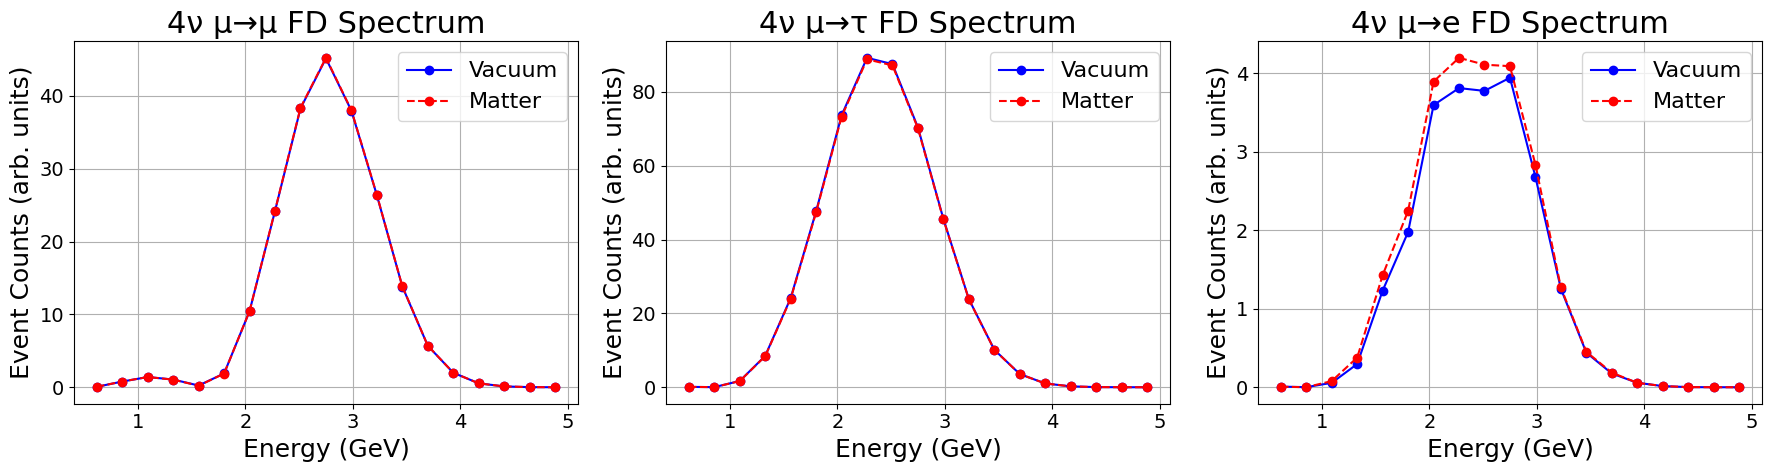

In [83]:
plt.figure(figsize=(18,5))
for i, trans in enumerate(transitions):
    vacuum_spec = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition=trans, case='vacuum')
                              for E in bin_centers])
    matter_spec = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition=trans, case='matter')
                              for E in bin_centers])
    ax = plt.subplot(1,3,i+1)
    ax.plot(bin_centers/1e9, vacuum_spec, 'b-o', label='Vacuum')
    ax.plot(bin_centers/1e9, matter_spec, 'r--o', label='Matter')
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel("Event Counts (arb. units)")
    ax.set_title("4ν " + titles[trans] + " FD Spectrum")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


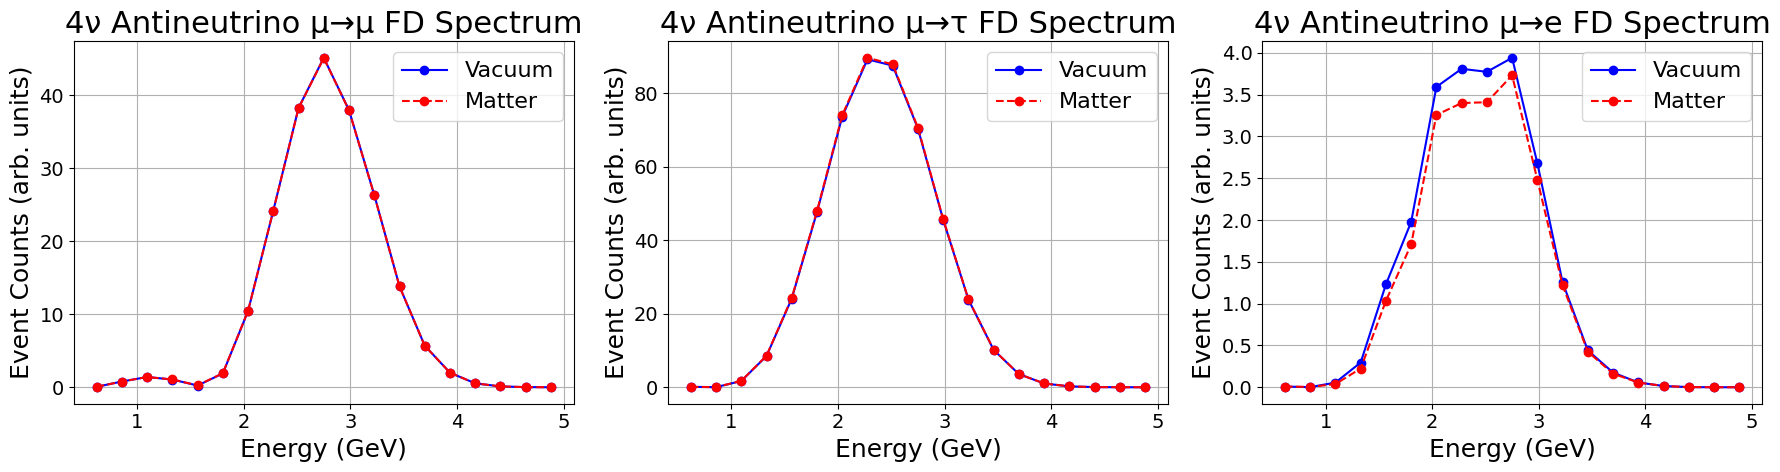

In [84]:
plt.figure(figsize=(18,5))
for i, trans in enumerate(transitions):
    vacuum_spec = np.array([gaussian(E, *popt_nd) * probability_4nu_antinue(E, Length_far, transition=trans, case='vacuum')
                              for E in bin_centers])
    matter_spec = np.array([gaussian(E, *popt_nd) * probability_4nu_antinue(E, Length_far, transition=trans, case='matter')
                              for E in bin_centers])
    ax = plt.subplot(1,3,i+1)
    ax.plot(bin_centers/1e9, vacuum_spec, 'b-o', label='Vacuum')
    ax.plot(bin_centers/1e9, matter_spec, 'r--o', label='Matter')
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel("Event Counts (arb. units)")
    ax.set_title("4ν Antineutrino " + titles[trans] + " FD Spectrum")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


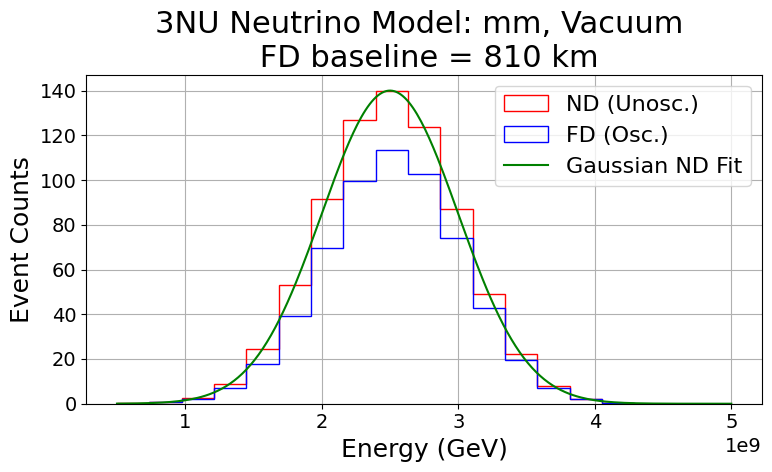

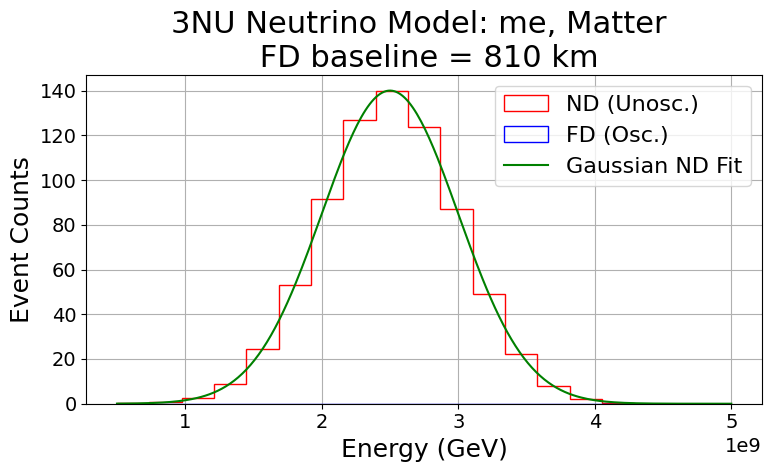

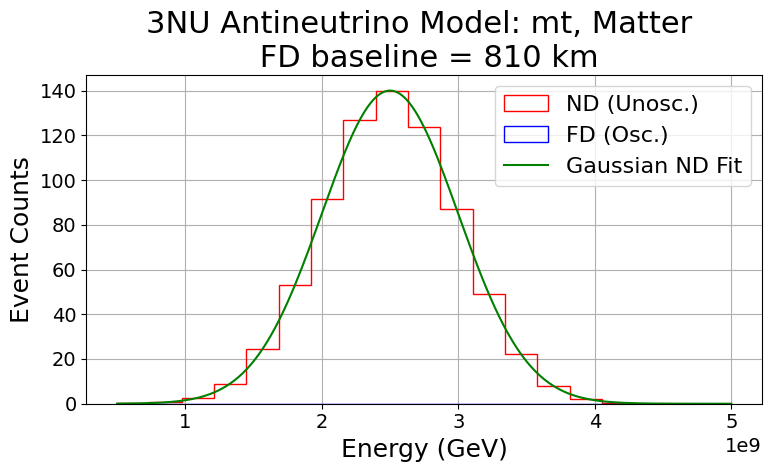

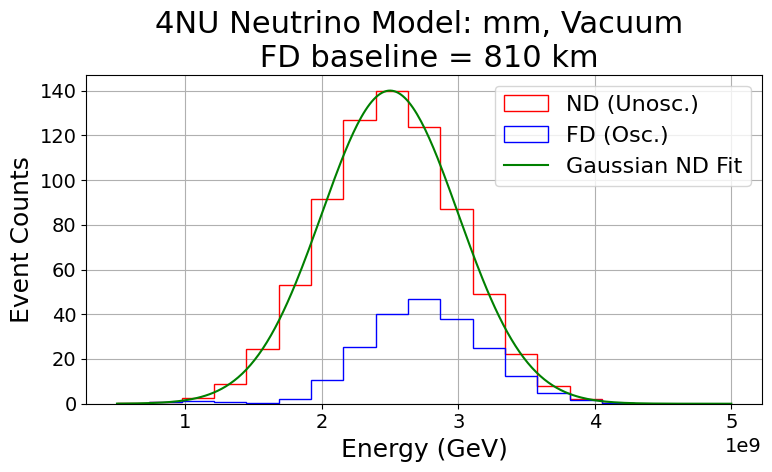

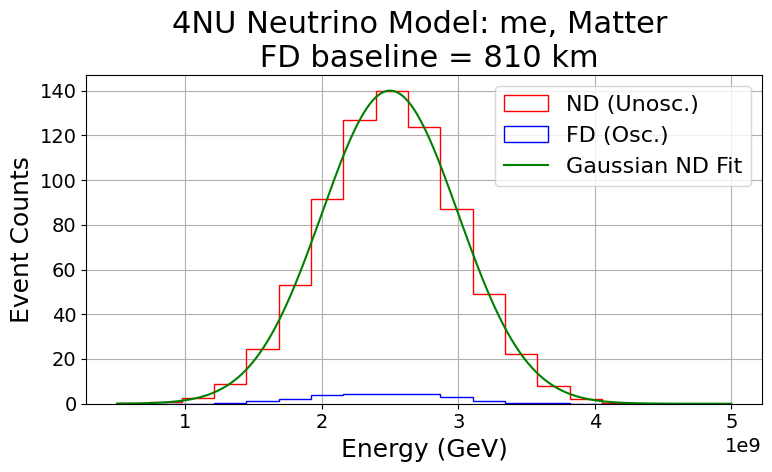

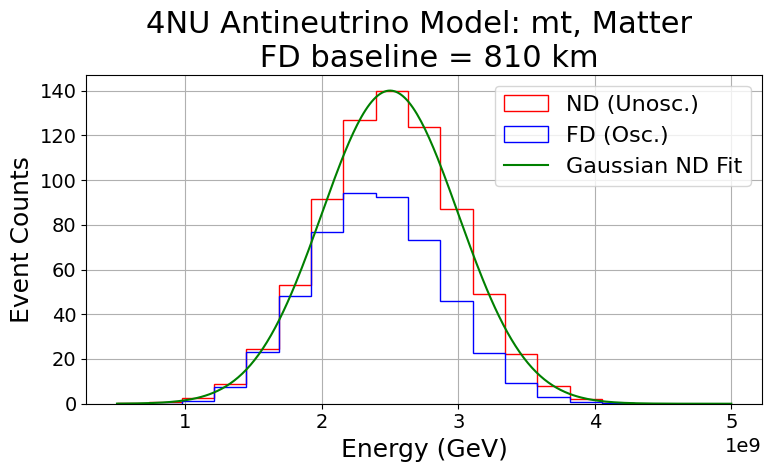

In [85]:
# Global conversions
CONV_KM_TO_INV_EV = 5.067731e9
VCC_EARTH_CRUST   = 7.6e-14

# 3-flavor standard parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0
D21     = 7.39e-5   # eV²
D31     = 2.525e-3  # eV²

# 4-flavor additional parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0
D41     = 1.0       # eV²

# FD baseline
Length_far = 810  # km

# Energy bins for the ND flux (example: 19 bins from 0.5–5 GeV, in eV)
bin_edges = np.linspace(0.5e9, 5e9, 20)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

# ND flux shape: let's assume a known Gaussian fit (popt_nd)
popt_nd = [140, 2.5e9, 0.5e9]  # [amplitude, mean(eV), sigma(eV)]

def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2)/(2*sigma**2))

# We create ND_counts by evaluating the Gaussian at each bin center
ND_counts = gaussian(bin_centers, *popt_nd)
# Optionally Poisson fluctuate the ND counts to simulate real data
# ND_counts = np.random.poisson(ND_counts).astype(float)

# (1) 3-flavor functions
import oscprob3nu
import hamiltonians3nu

def probability_3nu(E, L, transition='mm', matter=False, antineutrino=False):
    """
    Compute 3-flavor oscillation probability using NuOscProbExact for either
    neutrinos or antineutrinos, in vacuum or matter.

    E: Energy in eV
    L: Baseline in km
    transition: 'mm','me','mt' => mu->mu, mu->e, mu->tau
    matter: bool => if True, add matter potential
    antineutrino: bool => if True, flip sign of matter potential
    """
    # Build vacuum Hamiltonian
    h0 = np.array(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        theta12/np.pi*180/180,  # or from globaldefs
        theta23/np.pi*180/180,
        theta13/np.pi*180/180,
        delta13,
        D21, D31))  # Actually, might need a sin() approach if your code does so
    # Multiply by 1/E
    H = h0/E
    # Matter
    if matter:
        sign = -1.0 if antineutrino else 1.0
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, sign*VCC_EARTH_CRUST)
    # Evolve
    from globaldefs import CONV_KM_TO_INV_EV
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    # prob array => [Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt]
    # We won't call probabilities_3nu directly; we replicate logic:
    # But let's do it manually:
    # Pee = abs(S[0,0])^2, Pem=abs(S[0,1])^2, Pme=abs(S[1,0])^2, etc.
    if transition=='mm':
        return (S[1,1].real**2 + S[1,1].imag**2)
    elif transition=='me':
        return (S[1,0].real**2 + S[1,0].imag**2)
    elif transition=='mt':
        return (S[1,2].real**2 + S[1,2].imag**2)
    return 0

# (2) 4-flavor functions
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13), c12*c23 - s12*s13*s23*np.exp(1j*delta13), c13*s23, s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13), -c12*s23 - s12*s13*c23*np.exp(1j*delta13), c13*c23, c24*s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(E):
    # build vacuum Hamiltonian from global param
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2*E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    # Add matter potential
    return H_vac + np.diag([VCC,0,0,0])

def probability_4nu(E, L, transition='mm', matter=False, antineutrino=False):
    H_vac = hamiltonian_4nu_vacuum(E)
    if matter:
        sign = -1.0 if antineutrino else 1.0
        H = hamiltonian_4nu_matter(H_vac, E, sign*VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    idx_mu = 1  # row=1 is mu
    if transition=='mm':
        return np.abs(S[idx_mu, idx_mu])**2
    elif transition=='me':
        return np.abs(S[idx_mu,0])**2
    elif transition=='mt':
        return np.abs(S[idx_mu,2])**2
    elif transition=='ms':
        return np.abs(S[idx_mu,3])**2
    return 0

def plot_ND_FD_spectrum(transition='mm', model='3nu', matter=False, antineutrino=False):
    """
    Produce a single figure with:
      - ND histogram (unoscillated) in red
      - FD histogram (oscillated) in blue
      - Gaussian fit line over ND histogram in green
    """
    # 1) ND histogram
    ND_counts = gaussian(bin_centers, *popt_nd)

    # 2) Fit a Gaussian to ND
    def gaus(x, A, mu, sigma):
        return A * np.exp(-((x - mu)**2)/(2*sigma**2))
    popt_fit, _ = curve_fit(gaus, bin_centers, ND_counts, p0=[np.max(ND_counts), 2.5e9, 0.5e9])

    # 3) FD histogram: ND_counts * oscillation probability at FD baseline
    FD_counts = []
    for E in bin_centers:
        if model=='3nu':
            p = probability_3nu(E, Length_far, transition=transition, matter=matter, antineutrino=antineutrino)
        elif model=='4nu':
            p = probability_4nu(E, Length_far, transition=transition, matter=matter, antineutrino=antineutrino)
        else:
            p=1.0
        FD_counts.append(ND_counts[list(bin_centers).index(E)] * p)
    FD_counts = np.array(FD_counts)

    # 4) Plot hist + fit
    plt.figure(figsize=(8,5))

    # ND hist
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=ND_counts, histtype='step', color='red', label='ND (Unosc.)')
    # FD hist
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=FD_counts, histtype='step', color='blue', label='FD (Osc.)')

    # Overplot the ND Gaussian fit line
    x_vals = np.linspace(bin_edges[0], bin_edges[-1], 300)
    fit_vals = gaus(x_vals, *popt_fit)
    plt.plot(x_vals, fit_vals, 'g-', label='Gaussian ND Fit')

    # Title and labels
    # Build a descriptive title
    mat_str   = 'Matter' if matter else 'Vacuum'
    anti_str  = ' Antineutrino' if antineutrino else ' Neutrino'
    plt.title(f"{model.upper()}{anti_str} Model: {transition}, {mat_str} \n FD baseline = {Length_far} km")
    plt.xlabel("Energy (GeV)")
    plt.ylabel("Event Counts")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 1) 3ν neutrino, vacuum, mu->mu
plot_ND_FD_spectrum(transition='mm', model='3nu', matter=False, antineutrino=False)

# 2) 3ν neutrino, matter, mu->e
plot_ND_FD_spectrum(transition='me', model='3nu', matter=True, antineutrino=False)

# 3) 3ν antineutrino, matter, mu->tau
plot_ND_FD_spectrum(transition='mt', model='3nu', matter=True, antineutrino=True)

# 4) 4ν neutrino, vacuum, mu->mu
plot_ND_FD_spectrum(transition='mm', model='4nu', matter=False, antineutrino=False)

# 5) 4ν neutrino, matter, mu->e
plot_ND_FD_spectrum(transition='me', model='4nu', matter=True, antineutrino=False)

# 6) 4ν antineutrino, matter, mu->tau
plot_ND_FD_spectrum(transition='mt', model='4nu', matter=True, antineutrino=True)

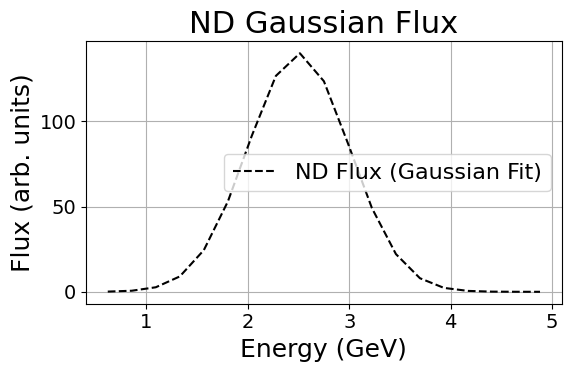

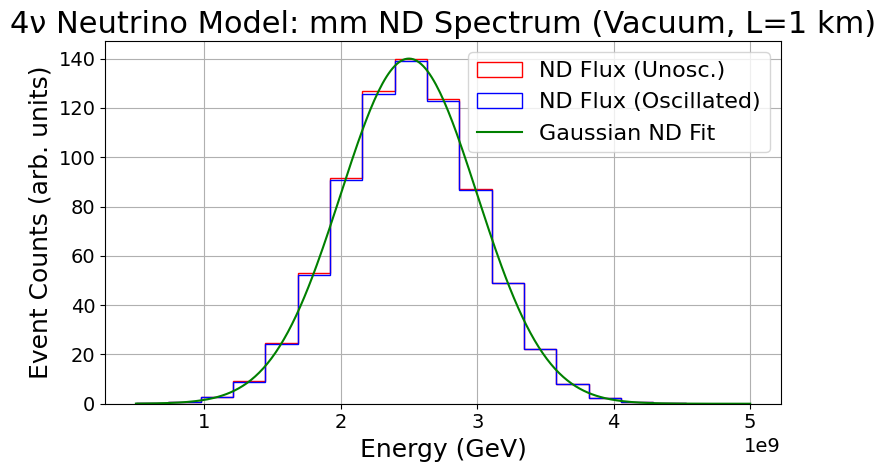

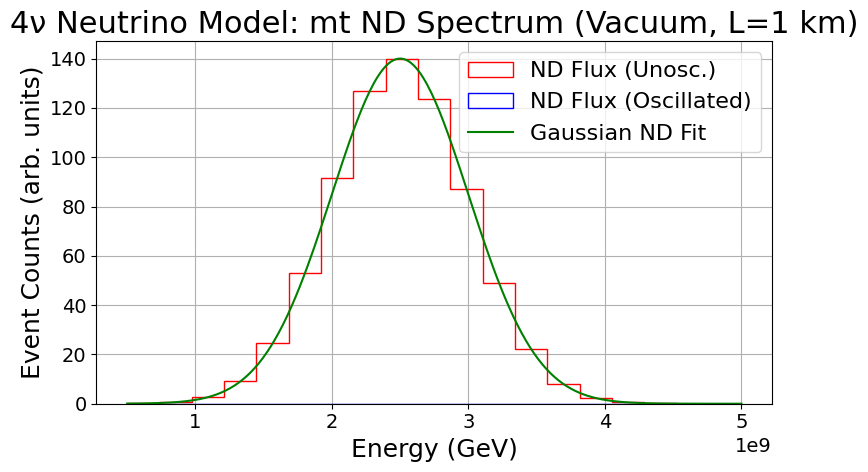

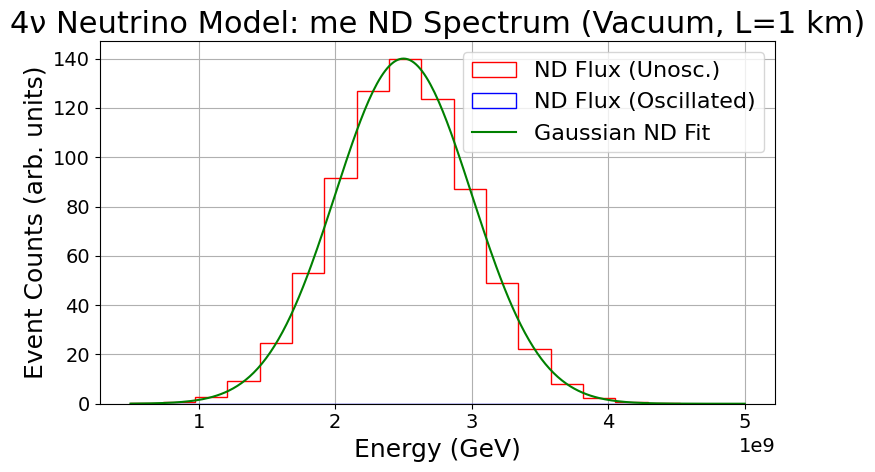

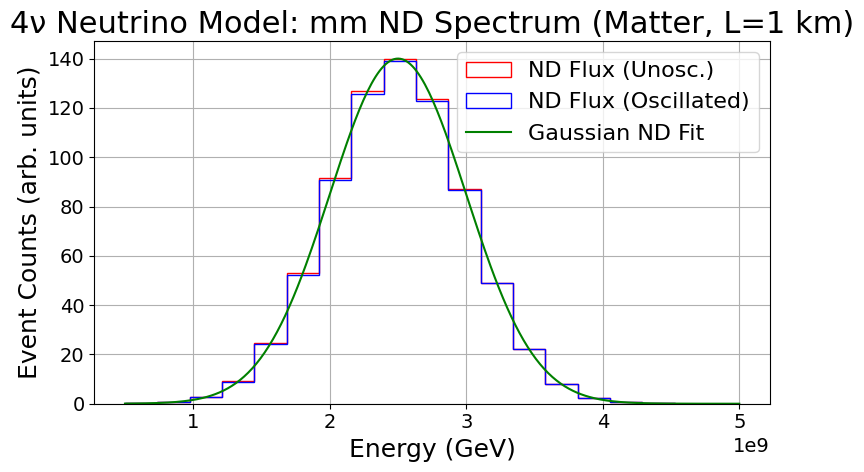

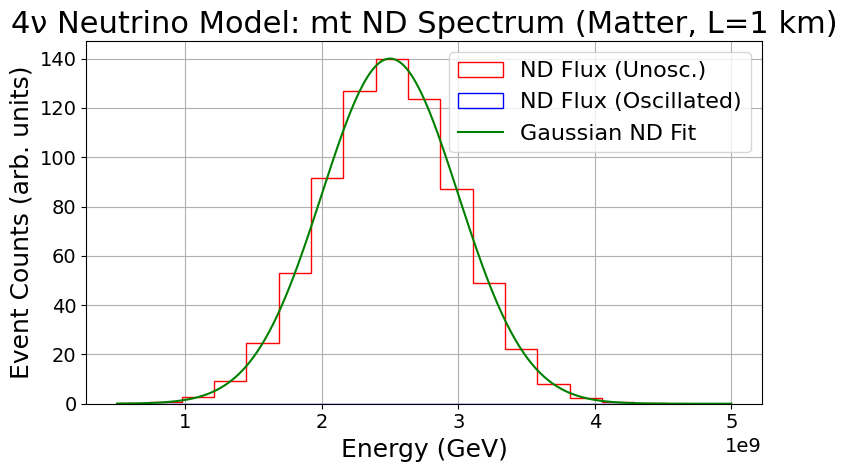

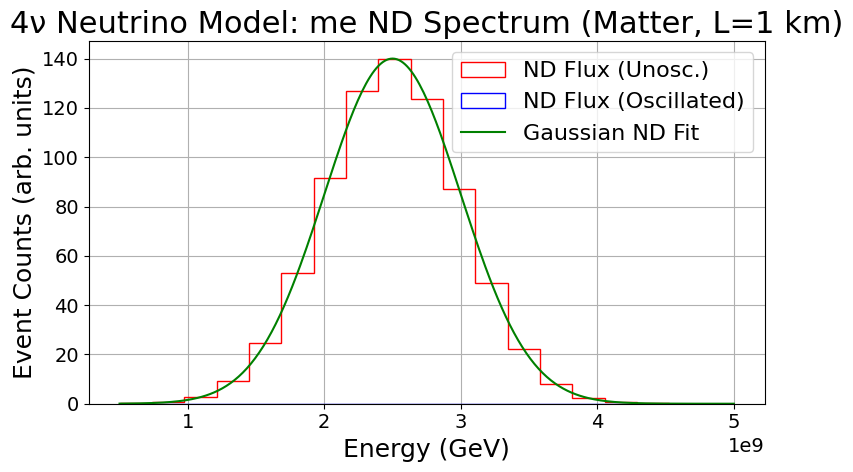

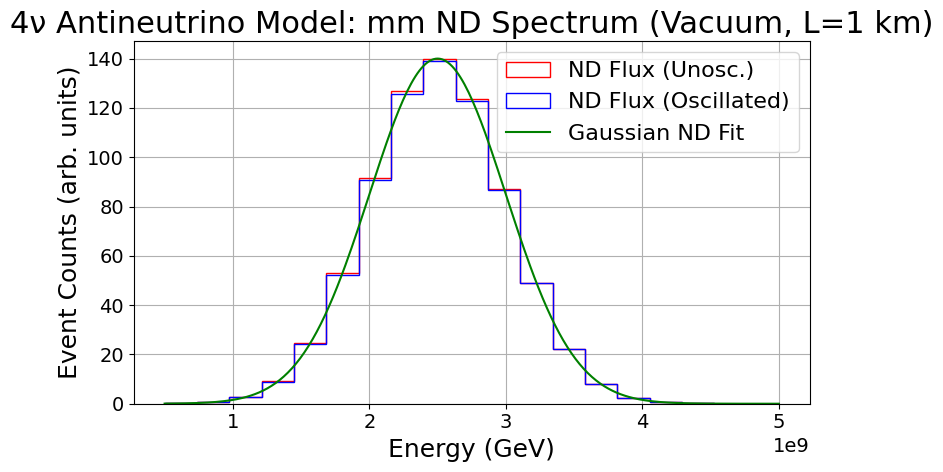

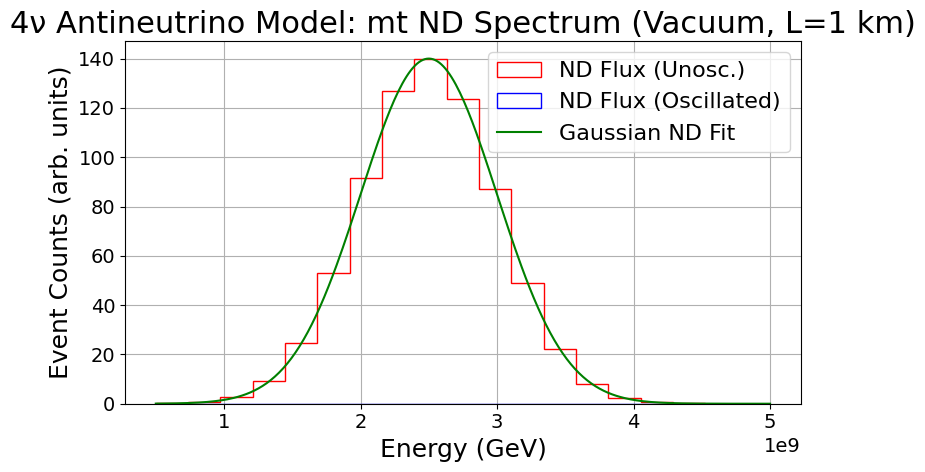

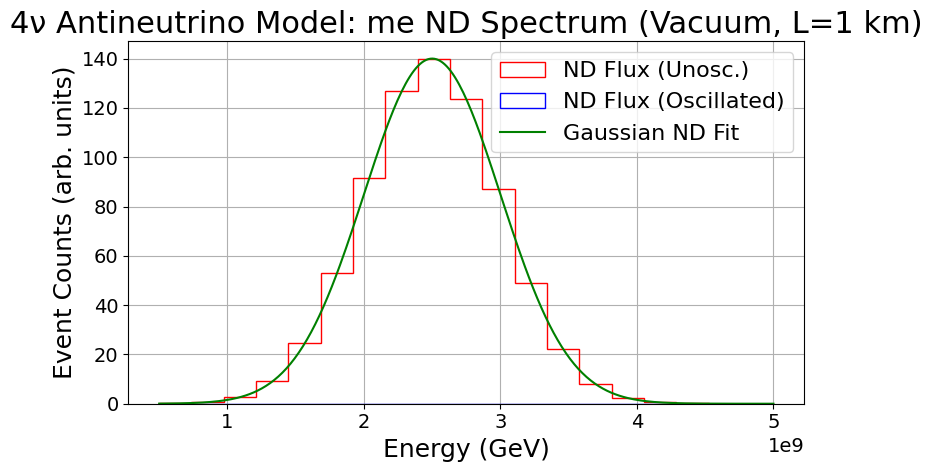

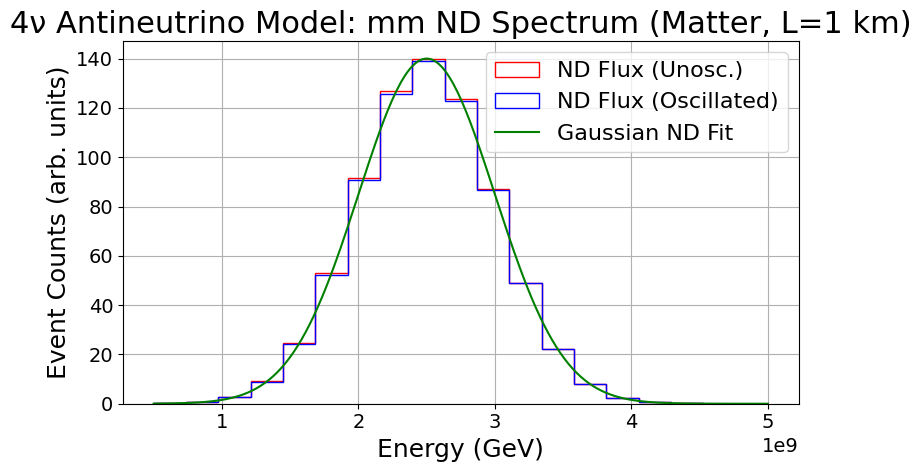

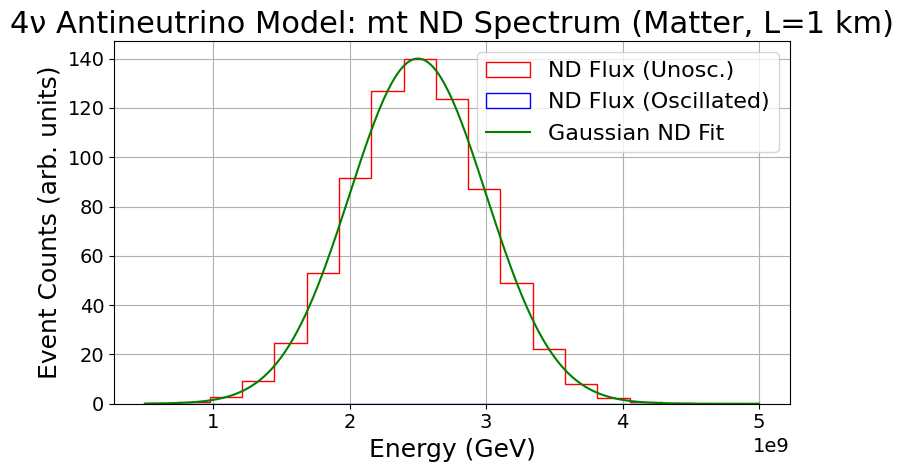

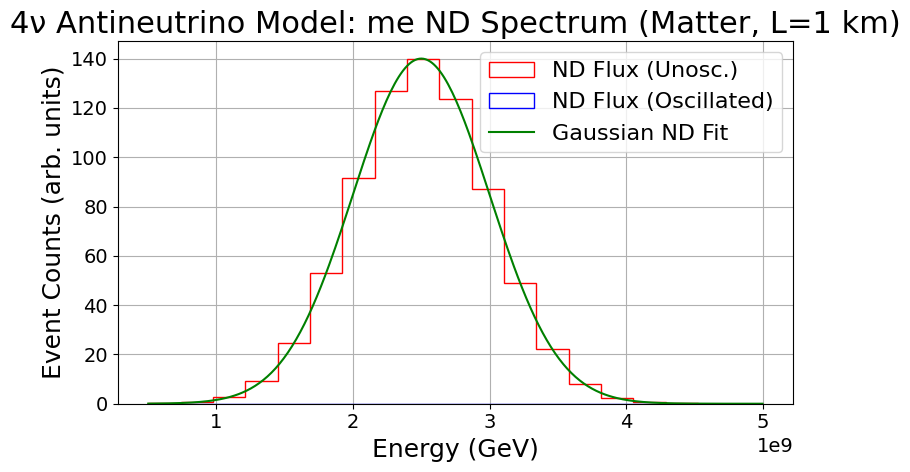

In [86]:
# 3-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0
D21     = 7.39e-5   # eV^2
D31     = 2.525e-3  # eV^2

# 4-flavor additional parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0
D41     = 1.0       # eV^2

# ND baseline
Length_near = 1   # km

# Define ND flux bins (in eV); here 19 bins from 0.5 GeV to 5 GeV
bin_edges = np.linspace(0.5e9, 5e9, 20)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Assume a Gaussian fit to ND flux (obtained from ND data)
popt_nd = [140, 2.5e9, 0.5e9]  # [Amplitude, Mean (in eV), Sigma (in eV)]

def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# (Optional ND flux plot)
plt.figure(figsize=(6,4))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux (Gaussian Fit)")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("ND Gaussian Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 4-Flavor Oscillation Functions ---
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13), c12*c23 - s12*s13*s23*np.exp(1j*delta13), c13*s23, s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13), -c12*s23 - s12*s13*c23*np.exp(1j*delta13), c13*c23, c24*s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    return H_vac + np.diag([VCC, 0, 0, 0])

def probability_4nu(E, L, transition='mm', case='vacuum', antineutrino=False):
    H_vac = hamiltonian_4nu_vacuum(E)
    if case == 'matter':
        sign = -1.0 if antineutrino else 1.0
        H = hamiltonian_4nu_matter(H_vac, E, sign * VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1,1])**2
    elif transition == 'me':
        return np.abs(S[1,0])**2
    elif transition == 'mt':
        return np.abs(S[1,2])**2
    elif transition == 'ms':
        return np.abs(S[1,3])**2
    return 0

def plot_ND_spectrum(transition='mm', model='4nu', matter=False, antineutrino=False, baseline=Length_near):
    """
    Plots the ND-style energy spectrum:
      - A histogram of the unoscillated ND flux (red)
      - A histogram of the “oscillated” ND flux = ND flux * oscillation probability (blue)
      - A Gaussian fit to the ND flux overlaid (green line)
    Parameters:
      transition: 'mm' (mu->mu), 'me' (mu->e), or 'mt' (mu->tau)
      model: '4nu' (only 4-flavor is used here)
      matter: bool, whether to use matter effects
      antineutrino: bool, whether to compute antineutrino probabilities
      baseline: detector baseline in km (for ND, baseline = 1 km)
    """
    # ND flux
    ND_flux = gaussian(bin_centers, *popt_nd)

    # Fit a Gaussian to ND_flux
    def gaus(x, A, mu, sigma):
        return A * np.exp(-((x - mu)**2)/(2*sigma**2))
    popt_fit, _ = curve_fit(gaus, bin_centers, ND_flux, p0=[np.max(ND_flux), 2.5e9, 0.5e9])

    # "Oscillated" ND flux = ND_flux * oscillation probability (computed at baseline)
    FD_flux = []
    for E in bin_centers:
        if model == '4nu':
            p = probability_4nu(E, baseline, transition=transition, case=('matter' if matter else 'vacuum'), antineutrino=antineutrino)
        else:
            p = 1.0
        FD_flux.append(ND_flux[list(bin_centers).index(E)] * p)
    FD_flux = np.array(FD_flux)

    plt.figure(figsize=(8,5))
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=ND_flux, histtype='step', color='red', label='ND Flux (Unosc.)')
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=FD_flux, histtype='step', color='blue', label='ND Flux (Oscillated)')
    x_vals = np.linspace(bin_edges[0], bin_edges[-1], 300)
    plt.plot(x_vals, gaus(x_vals, *popt_fit), 'g-', label='Gaussian ND Fit')

    mat_str = 'Matter' if matter else 'Vacuum'
    anti_str = 'Antineutrino' if antineutrino else 'Neutrino'
    plt.title(f"4ν {anti_str} Model: {transition} ND Spectrum ({mat_str}, L={baseline} km)")
    plt.xlabel("Energy (GeV)")
    plt.ylabel("Event Counts (arb. units)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Group A: 4ν Neutrino, Vacuum (antineutrino=False, matter=False)
for trans in ['mm', 'mt', 'me']:
    plot_ND_spectrum(transition=trans, model='4nu', matter=False, antineutrino=False, baseline=Length_near)

# Group B: 4ν Neutrino, Matter (antineutrino=False, matter=True)
for trans in ['mm', 'mt', 'me']:
    plot_ND_spectrum(transition=trans, model='4nu', matter=True, antineutrino=False, baseline=Length_near)

# Group C: 4ν Antineutrino, Vacuum (antineutrino=True, matter=False)
for trans in ['mm', 'mt', 'me']:
    plot_ND_spectrum(transition=trans, model='4nu', matter=False, antineutrino=True, baseline=Length_near)

# Group D: 4ν Antineutrino, Matter (antineutrino=True, matter=True)
for trans in ['mm', 'mt', 'me']:
    plot_ND_spectrum(transition=trans, model='4nu', matter=True, antineutrino=True, baseline=Length_near)


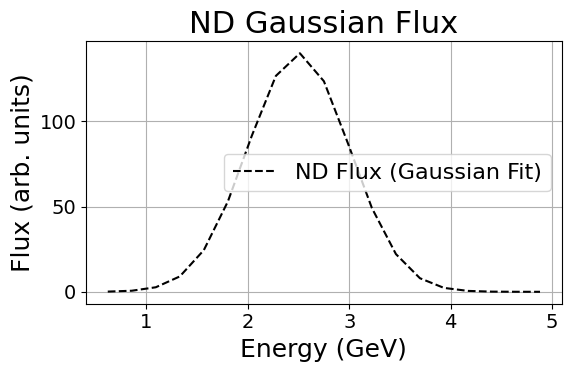

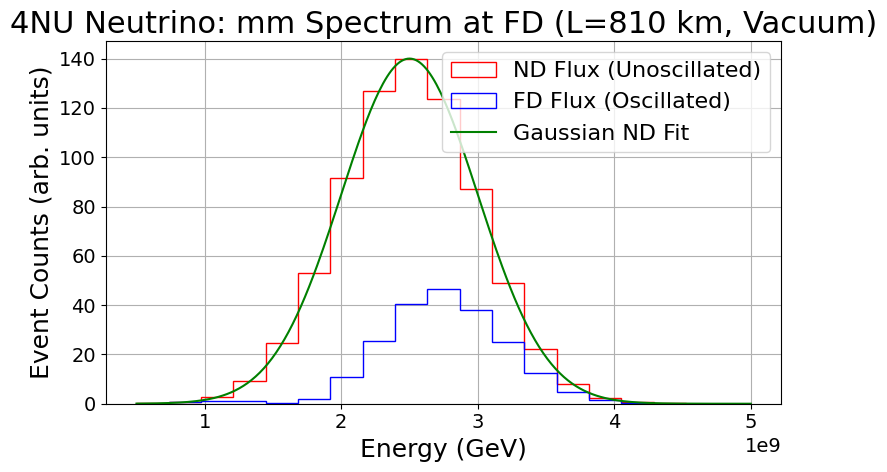

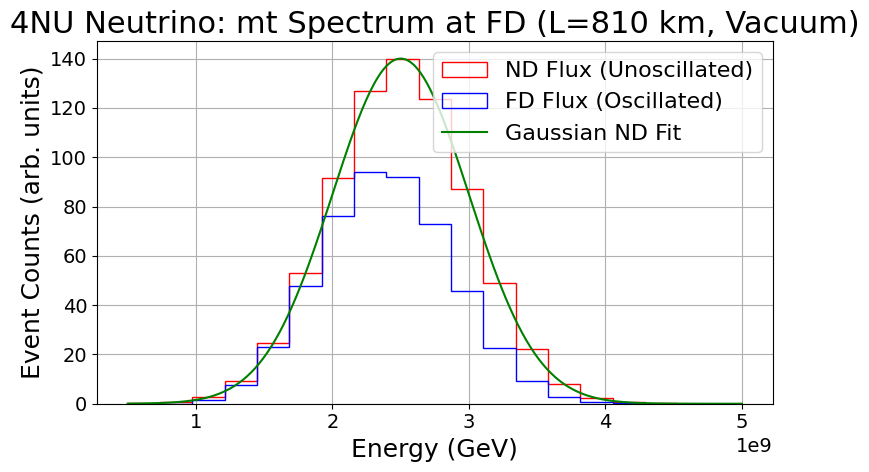

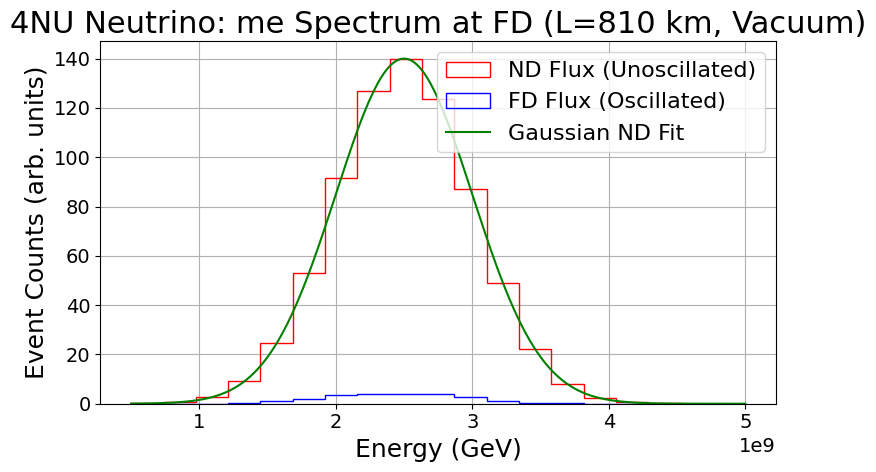

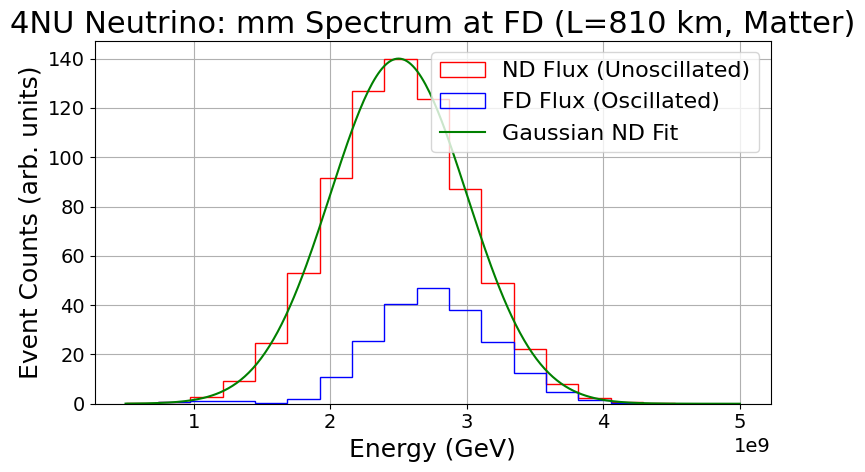

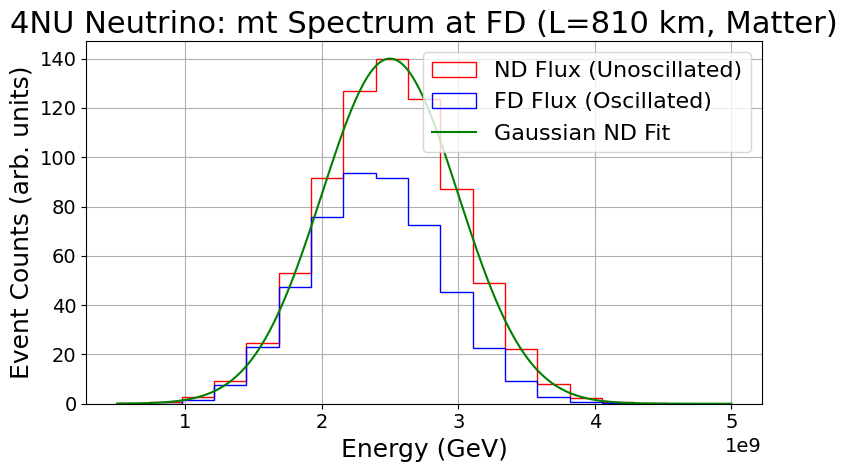

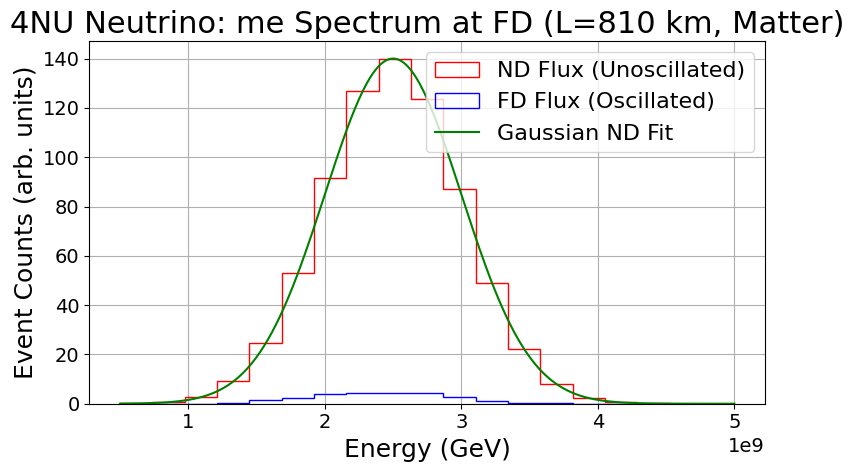

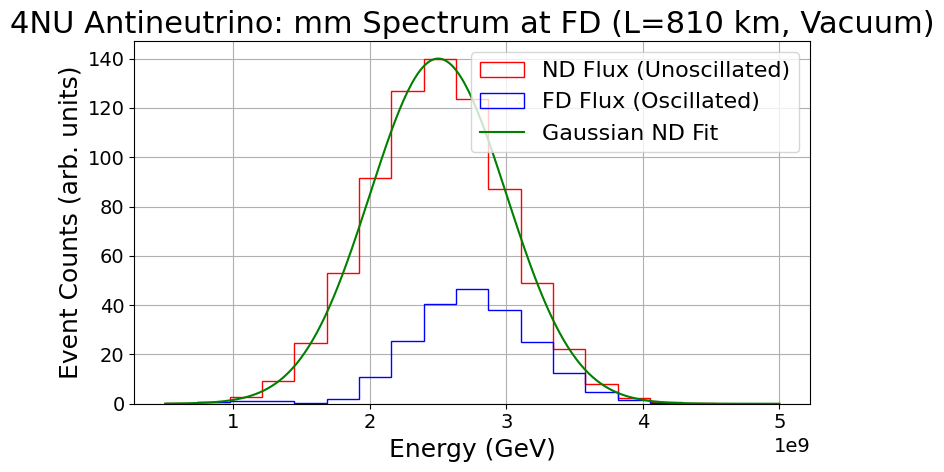

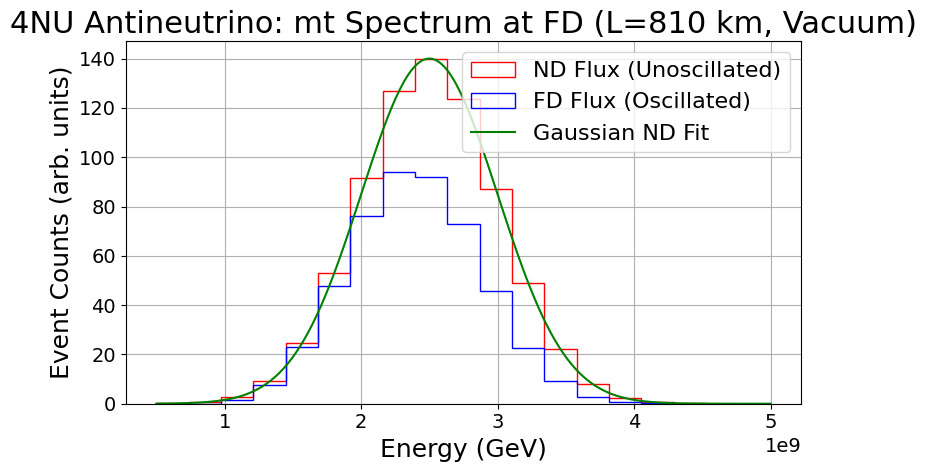

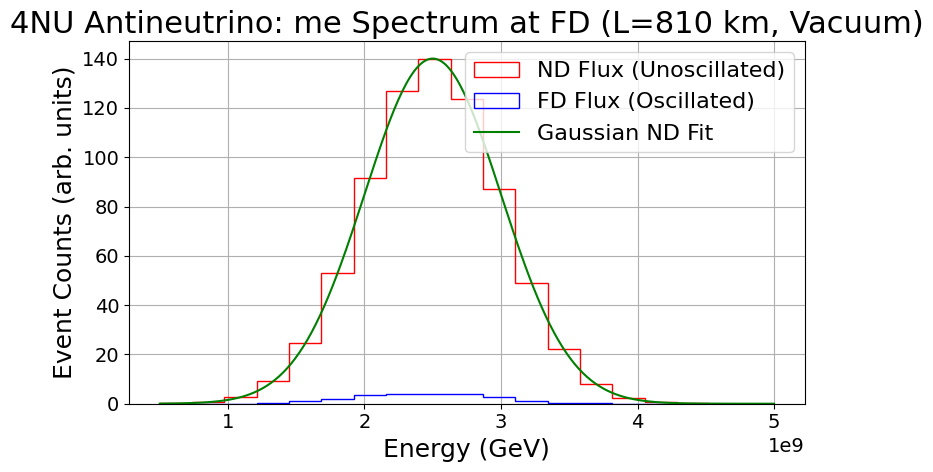

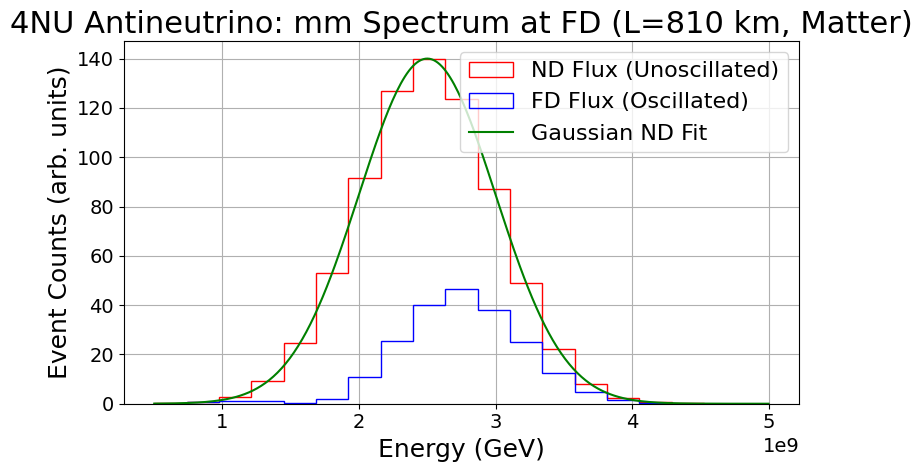

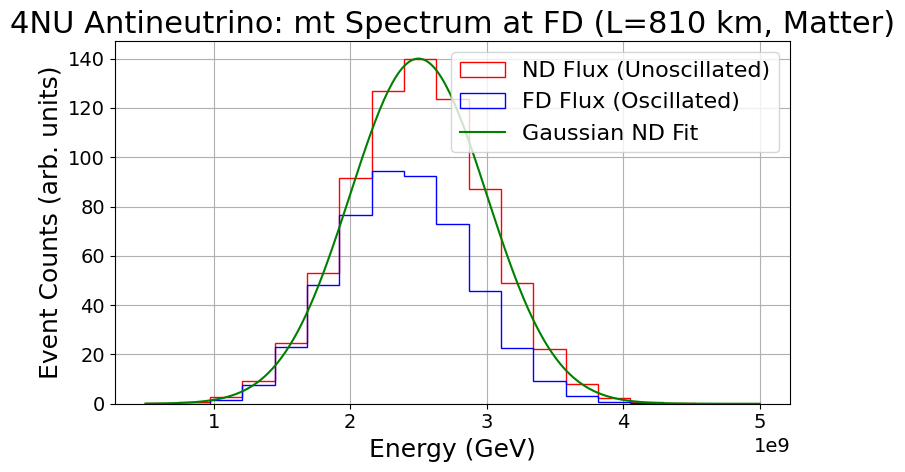

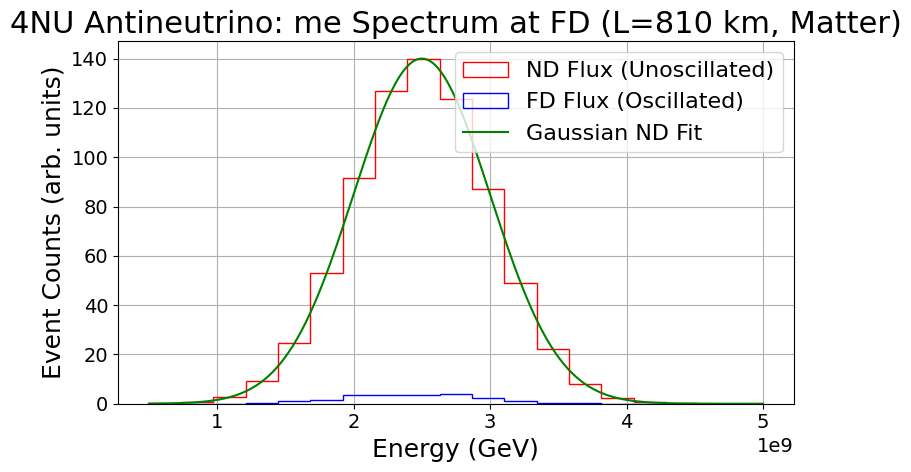

In [87]:
# Standard three-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                     # CP-phase (for 3ν; not used directly here)
D21     = 7.39e-5               # eV²
D31     = 2.525e-3              # eV²

# Additional four-flavor parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0                     # Extra CP-phase for sterile part
D41     = 1.0                   # eV²

# Far Detector baseline (FD)
Length_far = 810  # km

# ND Flux: define bin edges and centers (in eV, corresponding roughly to 0.5 - 5 GeV)
bin_edges = np.linspace(0.5e9, 5e9, 20)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# ND flux fit parameters (from your ND Gaussian fit)
popt_nd = [140, 2.5e9, 0.5e9]  # [Amplitude, Mean (eV), Sigma (eV)]

# Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2*sigma**2))

# (Optional: Plot ND flux for verification)
plt.figure(figsize=(6,4))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux (Gaussian Fit)")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("ND Gaussian Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13), c12*c23 - s12*s13*s23*np.exp(1j*delta13), c13*s23, s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13), -c12*s23 - s12*s13*c23*np.exp(1j*delta13), c13*c23, c24*s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    return H_vac + np.diag([VCC, 0, 0, 0])

def probability_4nu(E, L, transition='mm', case='vacuum', antineutrino=False):
    H_vac = hamiltonian_4nu_vacuum(E)
    if case == 'matter':
        sign = -1.0 if antineutrino else 1.0
        H = hamiltonian_4nu_matter(H_vac, E, sign*VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    # For an initial muon neutrino, index 1 corresponds to μ
    if transition == 'mm':
        return np.abs(S[1,1])**2
    elif transition == 'me':
        return np.abs(S[1,0])**2
    elif transition == 'mt':
        return np.abs(S[1,2])**2
    elif transition == 'ms':
        return np.abs(S[1,3])**2
    return 0

def probability_4nu_antinue(E, L, transition='mm', case='vacuum'):
    return probability_4nu(E, L, transition=transition, case=case, antineutrino=True)

def plot_FD_spectrum(transition='mm', model='4nu', case='vacuum', antineutrino=False, baseline=Length_far):
    """
    Create an FD-style energy spectrum plot using ND flux folded with the oscillation probability
    computed at the FD baseline.
      - The unoscillated ND flux is shown as red histogram bars.
      - The oscillated FD flux is shown as blue histogram bars.
      - A Gaussian fit to the ND flux is overlaid in green.

    Parameters:
      transition: 'mm' (μ→μ), 'me' (μ→e), or 'mt' (μ→τ)
      model: '4nu' (here we are using 4-flavor model)
      case: 'vacuum' or 'matter'
      antineutrino: boolean flag for antineutrino calculation (flips VCC sign in matter)
      baseline: baseline in km (for FD, use Length_far = 810 km)
    """
    # Use ND flux from the Gaussian fit
    ND_flux = gaussian(bin_centers, *popt_nd)

    # Fit a Gaussian to ND_flux (simulate the ND fit procedure)
    def gaus(x, A, mu, sigma):
        return A * np.exp(-((x - mu)**2) / (2*sigma**2))
    popt_fit, _ = curve_fit(gaus, bin_centers, ND_flux, p0=[np.max(ND_flux), 2.5e9, 0.5e9])

    # Compute the "oscillated" FD flux: ND flux * oscillation probability computed at FD baseline
    FD_flux = []
    for E in bin_centers:
        if model == '4nu':
            if antineutrino:
                p = probability_4nu_antinue(E, baseline, transition=transition, case=case)
            else:
                p = probability_4nu(E, baseline, transition=transition, case=case)
        else:
            p = 1.0
        FD_flux.append(ND_flux[list(bin_centers).index(E)] * p)
    FD_flux = np.array(FD_flux)

    plt.figure(figsize=(8,5))
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=ND_flux, histtype='step', color='red', label='ND Flux (Unoscillated)')
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=FD_flux, histtype='step', color='blue', label='FD Flux (Oscillated)')
    x_vals = np.linspace(bin_edges[0], bin_edges[-1], 300)
    plt.plot(x_vals, gaus(x_vals, *popt_fit), 'g-', label='Gaussian ND Fit')

    # Build title description
    case_str = 'Vacuum' if case=='vacuum' else 'Matter'
    ant_str = 'Neutrino' if not antineutrino else 'Antineutrino'
    plt.title(f"{model.upper()} {ant_str}: {transition} Spectrum at FD (L={baseline} km, {case_str})")
    plt.xlabel("Energy (GeV)")  # Change to /1e9 for GeV if preferred
    plt.ylabel("Event Counts (arb. units)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Group A: 4ν Neutrino, Vacuum
for trans in ['mm', 'mt', 'me']:
    plot_FD_spectrum(transition=trans, model='4nu', case='vacuum', antineutrino=False, baseline=Length_far)

# Group B: 4ν Neutrino, Matter
for trans in ['mm', 'mt', 'me']:
    plot_FD_spectrum(transition=trans, model='4nu', case='matter', antineutrino=False, baseline=Length_far)

# Group C: 4ν Antineutrino, Vacuum
for trans in ['mm', 'mt', 'me']:
    plot_FD_spectrum(transition=trans, model='4nu', case='vacuum', antineutrino=True, baseline=Length_far)

# Group D: 4ν Antineutrino, Matter
for trans in ['mm', 'mt', 'me']:
    plot_FD_spectrum(transition=trans, model='4nu', case='matter', antineutrino=True, baseline=Length_far)


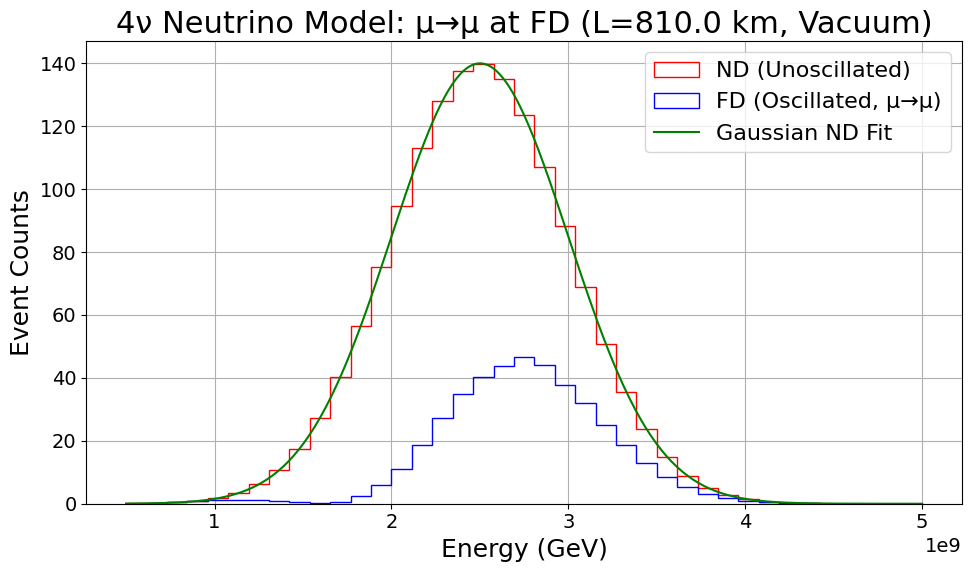

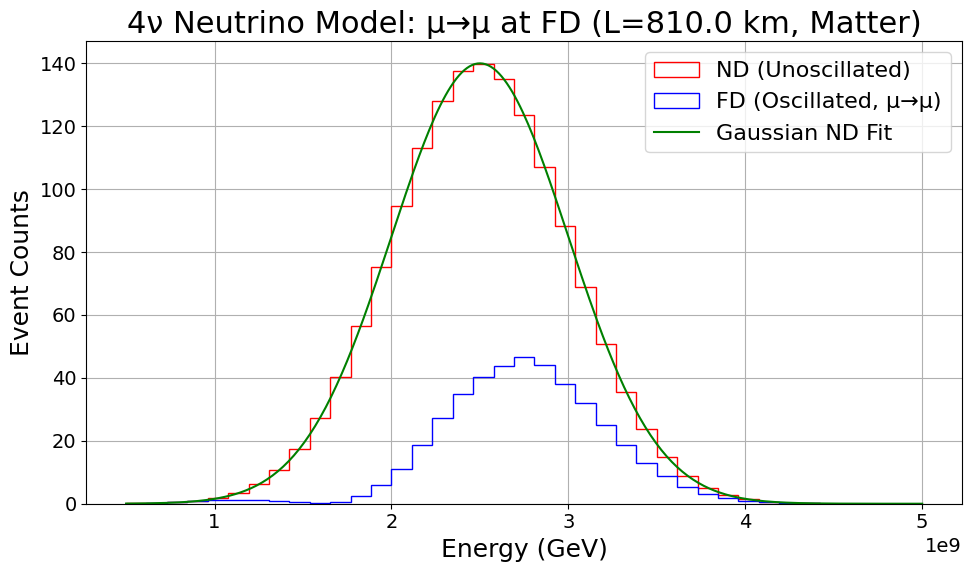

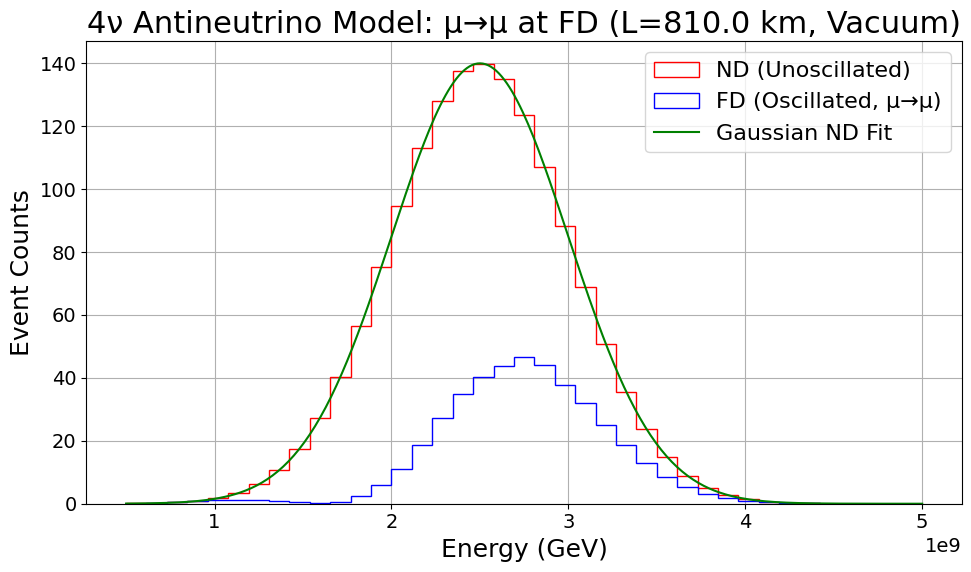

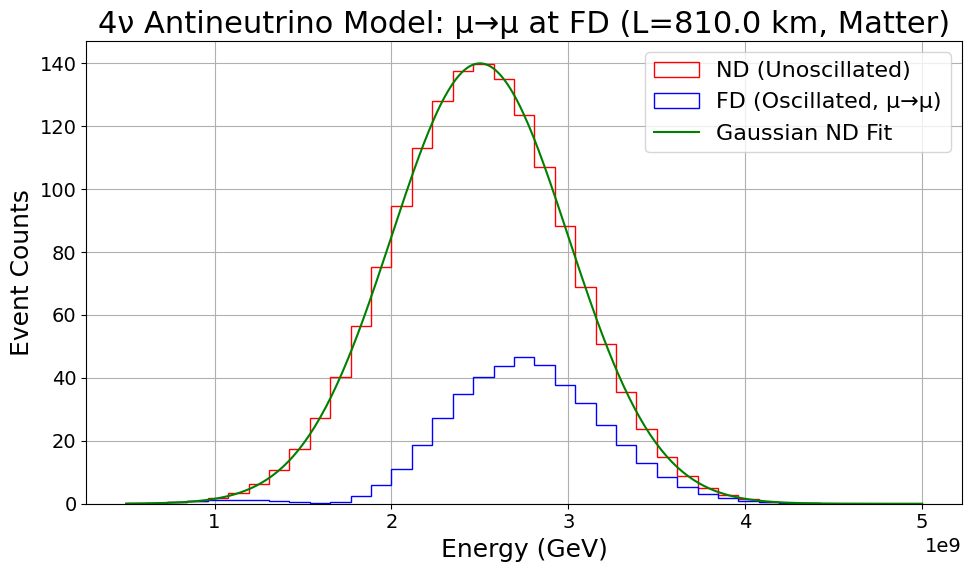

In [88]:
# Standard 3-flavor mixing parameters
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0
D21     = 7.39e-5    # eV²
D31     = 2.525e-3   # eV²

# Additional 4-flavor parameters for a sterile neutrino
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0
D41     = 1.0        # eV² (sterile); with ~1 eV² you can get multiple dips

# FD baseline
Length_far = 810.0   # km

# Define the bin edges for energies from 0.5 to 5 GeV, in eV
bin_edges = np.linspace(0.5e9, 5e9, 40)  # 39 bins instead of 19
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


# Assume a Gaussian fit from ND data
popt_nd = [140, 2.5e9, 0.5e9]  # amplitude, mean(eV), sigma(eV)
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2)/(2*sigma**2))

def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13), c12*c23 - s12*s13*s23*np.exp(1j*delta13), c13*s23, s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13), -c12*s23 - s12*s13*c23*np.exp(1j*delta13), c13*c23, c24*s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2.0 * E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    return H_vac + np.diag([VCC, 0, 0, 0])

def probability_4nu_mm(E, L, matter=False, antineutrino=False):
    """
    Muon survival probability in a 4-flavor model.
    matter: toggles matter effects
    antineutrino: if True => flips sign of VCC
    """
    H_vac = hamiltonian_4nu_vacuum(E)
    if matter:
        sign = -1.0 if antineutrino else 1.0
        H = hamiltonian_4nu_matter(H_vac, E, sign * VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    return np.abs(S[1,1])**2  # row=1 => muon flavor

def plot_ND_FD_spectrum_4nu_mm(matter=False, antineutrino=False, baseline=Length_far):
    """
    Creates a step-histogram plot showing:
      - ND flux (unoscillated) in red
      - FD flux (oscillated) in blue
      - Gaussian fit over ND flux in green
    This specifically uses the muon survival channel in a 4-flavor model,
    which can exhibit a double-peak structure for D41 ~ 1 eV² and L=810 km.
    """
    # 1) ND flux from the Gaussian
    ND_counts = gaussian(bin_centers, *popt_nd)

    # 2) Fit a Gaussian to ND_counts
    def gaus(x, A, mu, sigma):
        return A * np.exp(-((x - mu)**2)/(2*sigma**2))
    popt_fit, _ = curve_fit(gaus, bin_centers, ND_counts, p0=[np.max(ND_counts), 2.5e9, 0.5e9])

    # 3) FD flux: ND_counts * probability_4nu_mm(E, baseline, matter, antineutrino)
    FD_counts = []
    for E in bin_centers:
        p = probability_4nu_mm(E, baseline, matter=matter, antineutrino=antineutrino)
        FD_counts.append(ND_counts[list(bin_centers).index(E)] * p)
    FD_counts = np.array(FD_counts)

    # 4) Plot histograms
    plt.figure(figsize=(10,6))

    # ND histogram
    plt.hist(
        bin_edges[:-1],
        bins=bin_edges,
        weights=ND_counts,
        histtype='step',
        color='red',
        label='ND (Unoscillated)'
    )

    # FD histogram
    plt.hist(
        bin_edges[:-1],
        bins=bin_edges,
        weights=FD_counts,
        histtype='step',
        color='blue',
        label='FD (Oscillated, μ→μ)'
    )

    # Overplot the Gaussian ND fit
    xvals = np.linspace(bin_edges[0], bin_edges[-1], 300)
    yvals = gaus(xvals, *popt_fit)
    plt.plot(xvals, yvals, 'g-', label='Gaussian ND Fit')

    # Build a descriptive title
    mat_str = 'Matter' if matter else 'Vacuum'
    anti_str = 'Antineutrino' if antineutrino else 'Neutrino'
    plt.title(f"4ν {anti_str} Model: μ→μ at FD (L={baseline} km, {mat_str})")
    plt.xlabel("Energy (GeV)")  # optionally convert to GeV
    plt.ylabel("Event Counts")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Group A: neutrino, vacuum vs matter
plot_ND_FD_spectrum_4nu_mm(matter=False, antineutrino=False, baseline=Length_far)
plot_ND_FD_spectrum_4nu_mm(matter=True,  antineutrino=False, baseline=Length_far)

# Group B: antineutrino, vacuum vs matter
plot_ND_FD_spectrum_4nu_mm(matter=False, antineutrino=True,  baseline=Length_far)
plot_ND_FD_spectrum_4nu_mm(matter=True,  antineutrino=True,  baseline=Length_far)

def probability_4nu_mt(E, L, matter=False, antineutrino=False):
    H_vac = hamiltonian_4nu_vacuum(E)
    if matter:
        sign = -1.0 if antineutrino else 1.0
        H = hamiltonian_4nu_matter(H_vac, E, sign*VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    return np.abs(S[1,2])**2  # row=1 => mu, col=2 => tau

def probability_4nu_me(E, L, matter=False, antineutrino=False):
    H_vac = hamiltonian_4nu_vacuum(E)
    if matter:
        sign = -1.0 if antineutrino else 1.0
        H = hamiltonian_4nu_matter(H_vac, E, sign*VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    return np.abs(S[1,0])**2  # row=1 => mu, col=0 => e

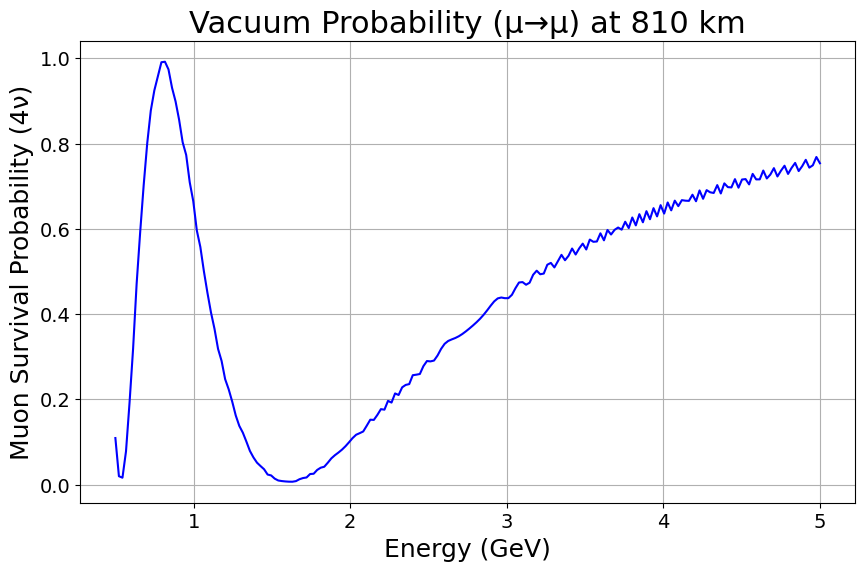

In [89]:
energies_GeV = np.linspace(0.5, 5, 200)
energies_eV = energies_GeV * 1e9
prob_mm = []
for E in energies_eV:
    p = probability_4nu(E, 810, transition='mm', case='vacuum')  # e.g., vacuum
    prob_mm.append(p)

plt.figure()
plt.plot(energies_GeV, prob_mm, 'b-')
plt.xlabel("Energy (GeV)")
plt.ylabel("Muon Survival Probability (4ν)")
plt.title("Vacuum Probability (μ→μ) at 810 km")
plt.grid(True)
plt.show()

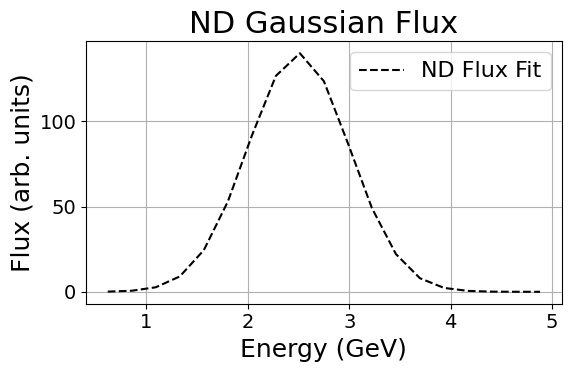

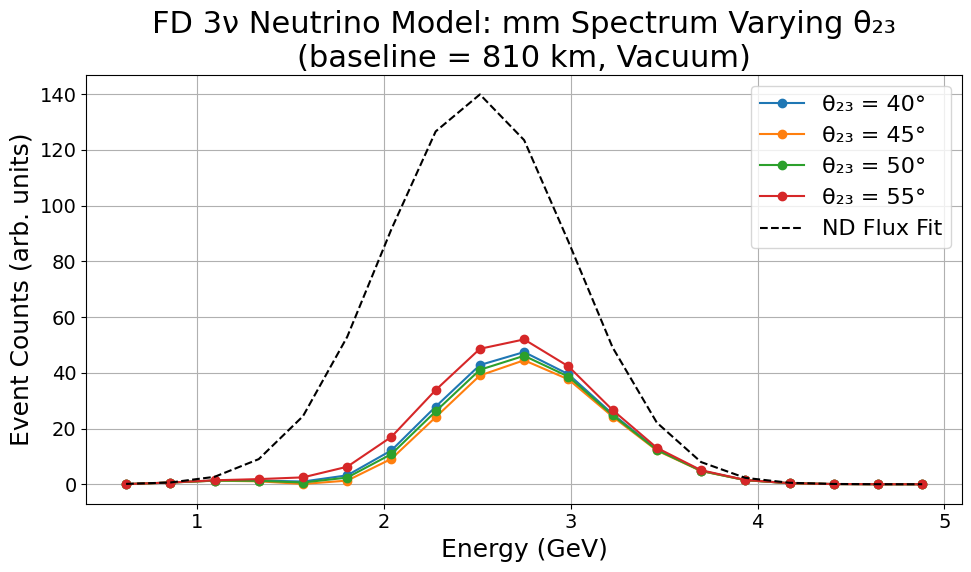

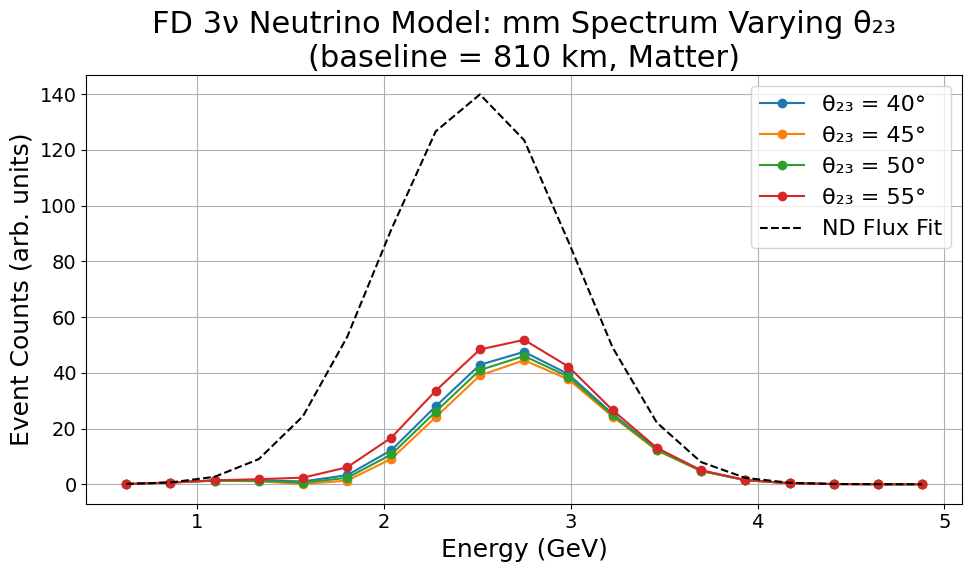

In [90]:
# Standard three-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
# We'll vary theta23 below.
delta13 = 0                     # CP phase (set to 0, can be varied)
D21 = 7.39e-5                   # Solar mass-squared difference [eV^2]
D31 = 2.525e-3                  # Atmospheric mass-squared difference [eV^2]

# FD baseline
Length_far = 810                # km

# ND flux: define bin edges and centers (using 19 bins from ~0.5 to 5 GeV, in eV)
bin_edges = np.linspace(0.5e9, 5e9, 20)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

# ND flux parameters from Gaussian fit (example values)
popt_nd = [140, 2.5e9, 0.5e9]  # [Amplitude, Mean in eV, Sigma in eV]

def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2*sigma**2))

# Optionally, plot the ND Gaussian flux:
plt.figure(figsize=(6,4))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux Fit")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("ND Gaussian Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

def probability_3nu_theta(E, L, theta23_val, matter=False, antineutrino=False, transition='mm'):
    """
    Computes the 3-flavor oscillation probability for energy E (in eV) and baseline L (in km)
    using a custom value for θ₂₃ (in radians). Other parameters are fixed (from globals).
    If matter=True, the matter potential (VCC_EARTH_CRUST) is added to the electron-flavor element.
    For antineutrinos, the sign of VCC is reversed.

    transition:
       'mm' -> νμ→νμ (muon survival)
       'me' -> νμ→νe
       'mt' -> νμ→ντ
    """
    # Construct the PMNS matrix with θ23 replaced by theta23_val using the standard parameterization
    U = np.array([
        [np.cos(theta12)*np.cos(theta13),
         np.sin(theta12)*np.cos(theta13),
         np.sin(theta13)*np.exp(-1j*delta13)],

        [-np.sin(theta12)*np.cos(theta23_val) - np.cos(theta12)*np.sin(theta13)*np.sin(theta23_val)*np.exp(1j*delta13),
         np.cos(theta12)*np.cos(theta23_val) - np.sin(theta12)*np.sin(theta13)*np.sin(theta23_val)*np.exp(1j*delta13),
         np.cos(theta13)*np.sin(theta23_val)],

        [np.sin(theta12)*np.sin(theta23_val) - np.cos(theta12)*np.sin(theta13)*np.cos(theta23_val)*np.exp(1j*delta13),
         -np.cos(theta12)*np.sin(theta23_val) - np.sin(theta12)*np.sin(theta13)*np.cos(theta23_val)*np.exp(1j*delta13),
         np.cos(theta13)*np.cos(theta23_val)]
    ])
    m2 = np.diag([0, D21, D31])
    H = U @ m2 @ np.conjugate(U.T) / (2.0 * E)
    if matter:
        sign = -1.0 if antineutrino else 1.0
        H = H + np.diag([sign*VCC_EARTH_CRUST, 0, 0])
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1,1])**2
    elif transition == 'me':
        return np.abs(S[1,0])**2
    elif transition == 'mt':
        return np.abs(S[1,2])**2
    return 0

def plot_FD_spectrum_3nu_theta(transition='mm', matter=False, antineutrino=False, baseline=Length_far):
    """
    For the three-flavor model, vary θ₂₃ over a range (e.g., 40°–55°)
    and produce an FD energy spectrum plot (using ND flux folded with oscillation probability)
    for the specified channel (transition). The plot will show one curve for each chosen value of θ₂₃.

    The ND flux is based on the Gaussian fit using parameters popt_nd.
    """
    # Define a set of θ₂₃ values in radians (e.g., 40°, 45°, 50°, 55°)
    theta23_vals = np.radians([40, 45, 50, 55])

    plt.figure(figsize=(10,6))
    for th in theta23_vals:
        FD_flux = []
        for E in bin_centers:
            p = probability_3nu_theta(E, baseline, theta23_val=th, matter=matter, antineutrino=antineutrino, transition=transition)
            FD_flux.append( gaussian(E, *popt_nd) * p )
        FD_flux = np.array(FD_flux)
        plt.plot(bin_centers/1e9, FD_flux, marker='o', linestyle='-', label=f"θ₂₃ = {np.degrees(th):.0f}°")

    # Overplot ND flux Gaussian for reference
    plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux Fit")

    med_str = 'Matter' if matter else 'Vacuum'
    ant_str = 'Antineutrino' if antineutrino else 'Neutrino'
    plt.xlabel("Energy (GeV)")
    plt.ylabel("Event Counts (arb. units)")
    plt.title(f"FD 3ν {ant_str} Model: {transition} Spectrum Varying θ₂₃\n(baseline = {baseline} km, {med_str})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 1) 3ν Neutrino, Vacuum, μ→μ
plot_FD_spectrum_3nu_theta(transition='mm', matter=False, antineutrino=False, baseline=Length_far)

# 2) 3ν Neutrino, Matter, μ→μ
plot_FD_spectrum_3nu_theta(transition='mm', matter=True, antineutrino=False, baseline=Length_far)

# Similarly, you can call with transition 'mt' or 'me' to see different channels.


In [91]:
# Define the standard mixing parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)   # You can vary this later
delta13 = 0                  # CP phase
D21     = 7.39e-5            # eV²
D31     = 2.525e-3           # eV²
VCC_EARTH_CRUST = 7.6e-14    # eV
CONV_KM_TO_INV_EV = 5.067731e9  # km⁻¹ to eV

# Define 3ν probability function (neutrino and antineutrino)
def probability_3nu(E, L, transition='mm', matter=False):
    """
    3-flavor oscillation probability with fixed theta23.
    transition: 'mm' (muon survival), 'me', or 'mt'
    """
    c12, c13, c23 = np.cos([theta12, theta13, theta23])
    s12, s13, s23 = np.sin([theta12, theta13, theta23])
    U = np.array([
        [c12*c13, s12*c13, s13*np.exp(-1j*delta13)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13),
         c12*c23 - s12*s13*s23*np.exp(1j*delta13),
         c13*s23],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13),
         -c12*s23 - s12*s13*c23*np.exp(1j*delta13),
         c13*c23]
    ])
    m2 = np.diag([0, D21, D31])
    H = U @ m2 @ np.conjugate(U.T) / (2 * E)
    if matter:
        H = H + np.diag([VCC_EARTH_CRUST, 0, 0])
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2

def probability_3nu_antinue(E, L, transition='mm', matter=False):
    """
    3-flavor oscillation for antineutrinos: flips sign of matter potential
    """
    c12, c13, c23 = np.cos([theta12, theta13, theta23])
    s12, s13, s23 = np.sin([theta12, theta13, theta23])
    U = np.array([
        [c12*c13, s12*c13, s13*np.exp(-1j*delta13)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13),
         c12*c23 - s12*s13*s23*np.exp(1j*delta13),
         c13*s23],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13),
         -c12*s23 - s12*s13*c23*np.exp(1j*delta13),
         c13*c23]
    ])
    m2 = np.diag([0, D21, D31])
    H = U @ m2 @ np.conjugate(U.T) / (2 * E)
    if matter:
        H = H + np.diag([-VCC_EARTH_CRUST, 0, 0])  # flip sign for antineutrinos
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2
# Now you can safely compute:
prob_mm_3nu_vac = [probability_3nu(E, Length_far, transition='mm', matter=False) for E in energies_eV]
prob_mm_3nu_mat = [probability_3nu(E, Length_far, transition='mm', matter=True) for E in energies_eV]
prob_mm_3nu_antivac = [probability_3nu_antinue(E, Length_far, transition='mm', matter=False) for E in energies_eV]
prob_mm_3nu_antimat = [probability_3nu_antinue(E, Length_far, transition='mm', matter=True) for E in energies_eV]


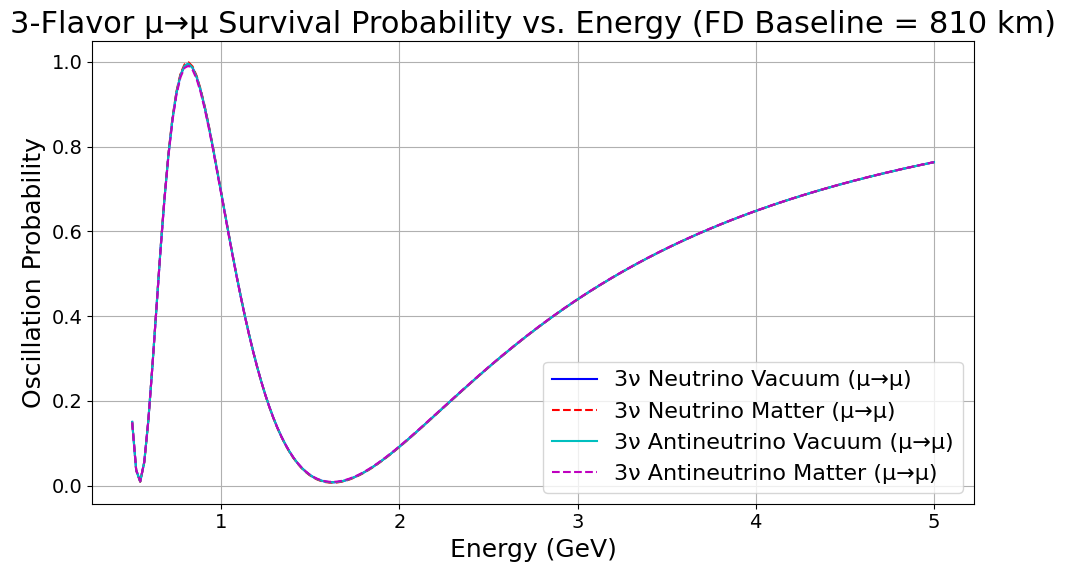

In [92]:
plt.figure(figsize=(10,6))
plt.plot(energies_GeV, prob_mm_3nu_vac, 'b-', label='3ν Neutrino Vacuum (μ→μ)')
plt.plot(energies_GeV, prob_mm_3nu_mat, 'r--', label='3ν Neutrino Matter (μ→μ)')
plt.plot(energies_GeV, prob_mm_3nu_antivac, 'c-', label='3ν Antineutrino Vacuum (μ→μ)')
plt.plot(energies_GeV, prob_mm_3nu_antimat, 'm--', label='3ν Antineutrino Matter (μ→μ)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("3-Flavor μ→μ Survival Probability vs. Energy (FD Baseline = 810 km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

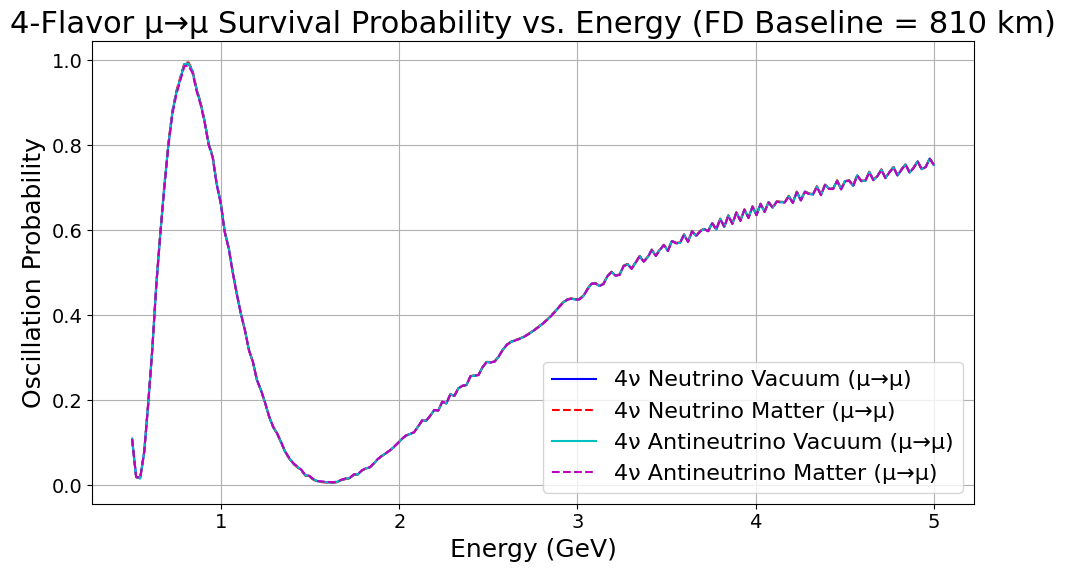

In [93]:
# FD baseline (810 km)
Length_far = 810  # km

# Energy range (0.5 to 5 GeV)
energies_GeV = np.linspace(0.5, 5, 200)
energies_eV = energies_GeV * 1e9

# Example: Plot 4ν muon survival probability for neutrinos and antineutrinos in vacuum and matter.
# (Assumes that probability_4nu and probability_4nu_antinue are defined as provided.)

# For neutrinos:
prob_mm_4nu_vac = [probability_4nu(E, Length_far, transition='mm', case='vacuum', antineutrino=False) for E in energies_eV]
prob_mm_4nu_mat = [probability_4nu(E, Length_far, transition='mm', case='matter', antineutrino=False) for E in energies_eV]

# For antineutrinos:
prob_mm_4nu_antivac = [probability_4nu_antinue(E, Length_far, transition='mm', case='vacuum') for E in energies_eV]
prob_mm_4nu_antimat = [probability_4nu_antinue(E, Length_far, transition='mm', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, prob_mm_4nu_vac, 'b-', label='4ν Neutrino Vacuum (μ→μ)')
plt.plot(energies_GeV, prob_mm_4nu_mat, 'r--', label='4ν Neutrino Matter (μ→μ)')
plt.plot(energies_GeV, prob_mm_4nu_antivac, 'c-', label='4ν Antineutrino Vacuum (μ→μ)')
plt.plot(energies_GeV, prob_mm_4nu_antimat, 'm--', label='4ν Antineutrino Matter (μ→μ)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("4-Flavor μ→μ Survival Probability vs. Energy (FD Baseline = 810 km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


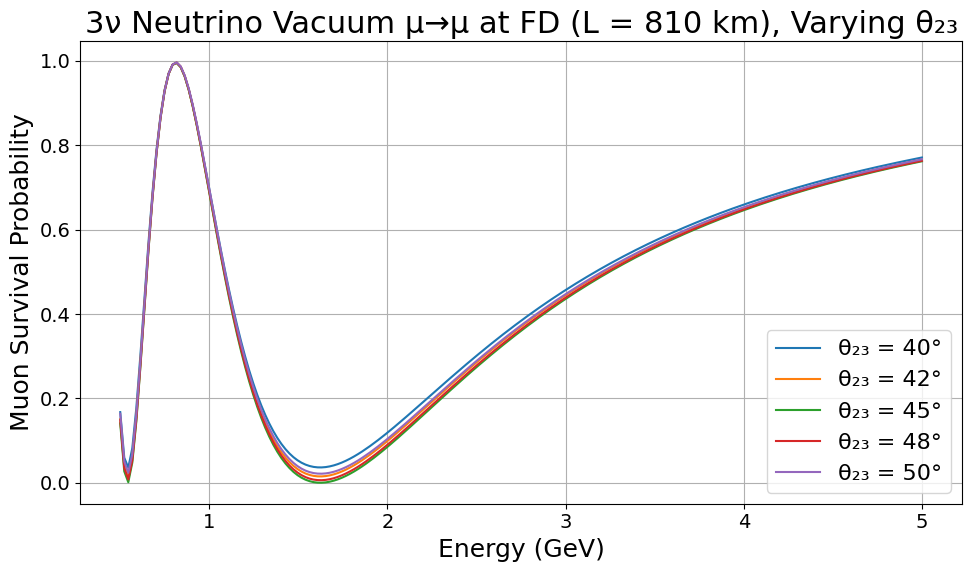

In [94]:
# Define theta23 values to test (in degrees), then convert to radians
theta23_degrees = [40, 42, 45, 48, 50]
theta23_radians = np.radians(theta23_degrees)

# Empty dictionary to store probability curves
prob_curves = {}

# Compute the oscillation probability for each theta23
for th_deg, th_rad in zip(theta23_degrees, theta23_radians):
    probs = [probability_3nu_theta(E, Length_far, theta23_val=th_rad, matter=False, antineutrino=False, transition='mm')
             for E in energies_eV]
    prob_curves[th_deg] = probs

# Plot the results
plt.figure(figsize=(10,6))
for th_deg in theta23_degrees:
    plt.plot(energies_GeV, prob_curves[th_deg], label=f"θ₂₃ = {th_deg}°")

plt.xlabel("Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("3ν Neutrino Vacuum μ→μ at FD (L = 810 km), Varying θ₂₃")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


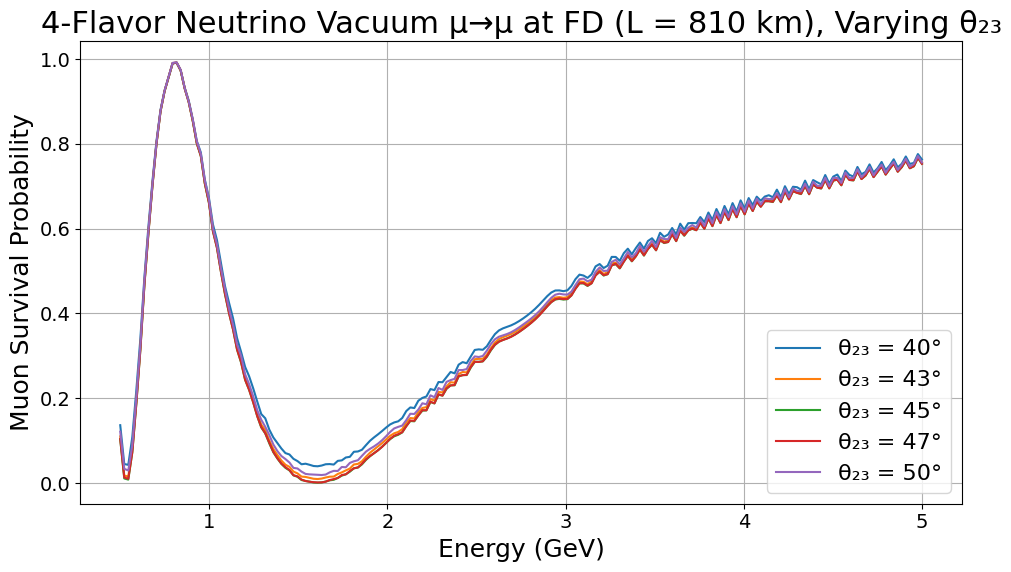

In [95]:
# Constants
CONV_KM_TO_INV_EV = 5.067731e9
VCC_EARTH_CRUST   = 7.6e-14

# Fixed mixing angles (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta13 = 0
delta14 = 0
D21 = 7.39e-5
D31 = 2.525e-3
D41 = 1.0  # eV^2 (sterile)

# Baseline
Length_far = 810  # km

# Energy range
energies_GeV = np.linspace(0.5, 5, 200)
energies_eV = energies_GeV * 1e9

# Function to build the mixing matrix with variable theta23
def mixing_matrix_4nu_variable_theta23(theta23_var):
    c12, c13, c14 = np.cos([theta12, theta13, theta14])
    s12, s13, s14 = np.sin([theta12, theta13, theta14])
    c23, c24, c34 = np.cos([theta23_var, theta24, theta34])
    s23, s24, s34 = np.sin([theta23_var, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13),
         c12*c23 - s12*s13*s23*np.exp(1j*delta13),
         c13*s23,
         s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13),
         -c12*s23 - s12*s13*c23*np.exp(1j*delta13),
         c13*c23,
         c24*s34],
        [0, 0, 0, c34]
    ])
    return U

# Hamiltonians
def hamiltonian_4nu_vacuum(E, theta23_var):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu_variable_theta23(theta23_var)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

# Probability function
def probability_4nu_mm(E, L, theta23_var, matter=False):
    H_vac = hamiltonian_4nu_vacuum(E, theta23_var)
    if matter:
        H = H_vac + np.diag([VCC_EARTH_CRUST, 0, 0, 0])
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    return np.abs(S[1,1])**2  # muon survival

# θ23 values to test (in degrees)
theta23_degrees = [40, 43, 45, 47, 50]
theta23_radians = np.radians(theta23_degrees)

# Plot
plt.figure(figsize=(10,6))
for th_deg, th_rad in zip(theta23_degrees, theta23_radians):
    probs = [probability_4nu_mm(E, Length_far, theta23_var=th_rad, matter=False) for E in energies_eV]
    plt.plot(energies_GeV, probs, label=f"θ₂₃ = {th_deg}°")

plt.xlabel("Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("4-Flavor Neutrino Vacuum μ→μ at FD (L = 810 km), Varying θ₂₃")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


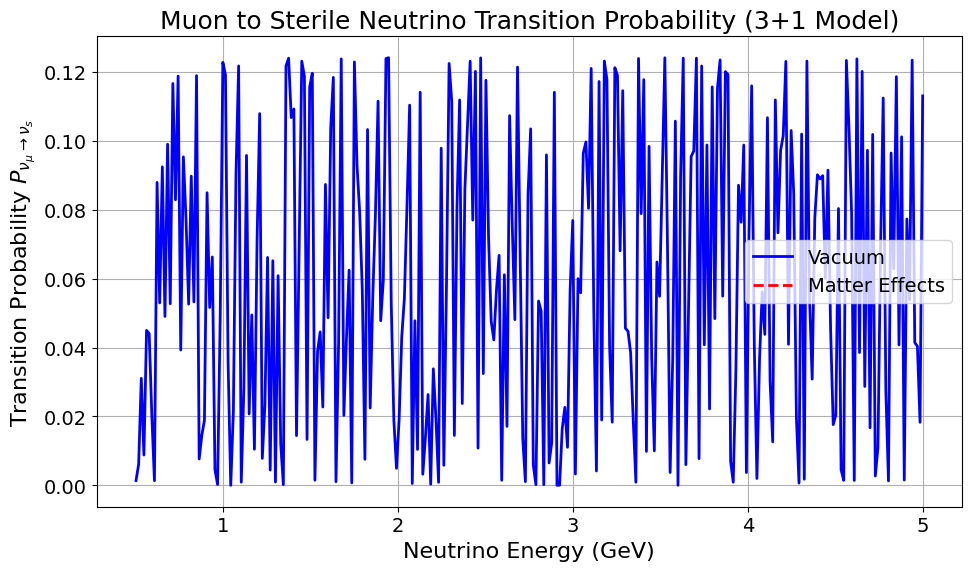

In [96]:
# Constants
G_F = 1.1663787e-5       # Fermi constant in GeV^-2
Na = 6.02214076e23       # Avogadro's number
Ye = 0.5                 # average electron fraction in Earth crust
rho = 2.8                # average Earth crust density in g/cm^3
L = 810                  # NOvA baseline in km
L_km_to_eV = 5.07e9      # km to eV^-1 conversion

# Oscillation parameters from Kopp et al. (2013)
delta_m41_sq = 1.78  # eV^2

# Mixing angles from sin^2(2theta)
theta_14 = np.arcsin(np.sqrt(0.089)) / 2
theta_24 = np.arcsin(np.sqrt(0.13)) / 2
theta_34 = 0.0  # assumed negligible

# Define approximate 4x4 mixing matrix
def U_matrix(theta_14, theta_24, theta_34):
    c14, s14 = np.cos(theta_14), np.sin(theta_14)
    c24, s24 = np.cos(theta_24), np.sin(theta_24)
    c34, s34 = np.cos(theta_34), np.sin(theta_34)

    # Approximate form (not full PMNS extended)
    U = np.array([
        [c14,       0,       0, s14],
        [-s14*s24,  c24,     0, c14*s24],
        [-s14*c24*s34, -s24*s34, c34, c14*c24*s34],
        [s14*c24*c34, s24*c34, s34, -c14*c24*c34]
    ])
    return U

# Main function to compute P(νμ → νs)
def compute_transition_probability(E, L, delta_m41_sq, theta_14, theta_24, theta_34, matter=False):
    U = U_matrix(theta_14, theta_24, theta_34)
    Delta = np.diag([0, 0, 0, delta_m41_sq]) / (2 * E)  # simplified mass splitting matrix
    H_vac = U @ Delta @ U.T

    if matter:
        # Add MSW matter potential: only electron neutrinos feel this
        V = np.zeros((4, 4))
        Ne = Ye * rho * Na * 1e-6  # electrons per cm^3 to per eV^3
        V[0, 0] = np.sqrt(2) * G_F * Ne
        H = H_vac + V
    else:
        H = H_vac

    # Convert L to natural units (eV^-1)
    L_eV = L * L_km_to_eV
    U_t = expm(-1j * H * L_eV)

    # State vectors
    nu_mu = np.array([0, 1, 0, 0])
    nu_s = np.array([0, 0, 0, 1])

    # Compute transition amplitude
    amp = np.dot(nu_s.conj().T, U_t @ nu_mu)
    prob = np.abs(amp)**2
    return prob

# Energy range
energies = np.linspace(0.5, 5.0, 300)  # GeV

# Calculate transition probabilities
probs_vac = [compute_transition_probability(E, L, delta_m41_sq, theta_14, theta_24, theta_34, matter=False) for E in energies]
probs_matter = [compute_transition_probability(E, L, delta_m41_sq, theta_14, theta_24, theta_34, matter=True) for E in energies]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(energies, probs_vac,      label='Vacuum',        color='blue', linewidth=2)
plt.plot(energies, probs_matter,   label='Matter Effects', color='red',  linestyle='--', linewidth=2)

plt.xlabel('Neutrino Energy (GeV)', fontsize=16)
plt.ylabel(r'Transition Probability $P_{\nu_\mu \rightarrow \nu_s}$', fontsize=16)
plt.title('Muon to Sterile Neutrino Transition Probability (3+1 Model)', fontsize=18)

# enlarge the tick labels
plt.tick_params(axis='both', which='major', labelsize=14)

plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


In [97]:
# --- Oscillation parameters from Kopp et al. (2013) ---
delta_m41_sq = 1.78  # eV^2
theta_14 = np.arcsin(np.sqrt(0.089)) / 2
theta_24 = np.arcsin(np.sqrt(0.13)) / 2
theta_34 = 0.0  # assumed negligible

# --- Mixing matrix approximation ---
def U_matrix(theta_14, theta_24, theta_34):
    c14, s14 = np.cos(theta_14), np.sin(theta_14)
    c24, s24 = np.cos(theta_24), np.sin(theta_24)
    c34, s34 = np.cos(theta_34), np.sin(theta_34)

    U = np.array([
        [c14,       0,       0, s14],
        [-s14*s24,  c24,     0, c14*s24],
        [-s14*c24*s34, -s24*s34, c34, c14*c24*s34],
        [s14*c24*c34, s24*c34, s34, -c14*c24*c34]
    ])
    return U

# --- Compute transition probability ---
def compute_transition_probability(E, L, delta_m41_sq, theta_14, theta_24, theta_34, matter=False):
    U = U_matrix(theta_14, theta_24, theta_34)
    Delta = np.diag([0, 0, 0, delta_m41_sq]) / (2 * E)
    H_vac = U @ Delta @ U.T

    if matter:
        V = np.zeros((4, 4))
        Ne = Ye * rho * Na * 1e-6  # convert to per eV^3
        V[0, 0] = np.sqrt(2) * G_F * Ne
        H = H_vac + V
    else:
        H = H_vac

    L_eV = L * L_km_to_eV
    U_t = expm(-1j * H * L_eV)

    nu_mu = np.array([0, 1, 0, 0])
    nu_s = np.array([0, 0, 0, 1])
    amp = np.dot(nu_s.conj().T, U_t @ nu_mu)
    return np.abs(amp)**2

# --- Energy range and calculation ---
energies = np.linspace(0.5, 5.0, 300)
probs_vac = [compute_transition_probability(E, L, delta_m41_sq, theta_14, theta_24, theta_34, matter=False) for E in energies]
probs_matter = [compute_transition_probability(E, L, delta_m41_sq, theta_14, theta_24, theta_34, matter=True) for E in energies]

# --- Store in DataFrame ---
df = pd.DataFrame({
    'Energy (GeV)': energies,
    'P_mu_to_s (Vacuum)': probs_vac,
    'P_mu_to_s (Matter)': probs_matter
})

print(df.head(15).to_string(index=False))


 Energy (GeV)  P_mu_to_s (Vacuum)  P_mu_to_s (Matter)
     0.500000            0.001392                 NaN
     0.515050            0.006116                 NaN
     0.530100            0.031071                 NaN
     0.545151            0.008807                 NaN
     0.560201            0.044992                 NaN
     0.575251            0.044062                 NaN
     0.590301            0.020418                 NaN
     0.605351            0.001347                 NaN
     0.620401            0.087944                 NaN
     0.635452            0.052964                 NaN
     0.650502            0.092461                 NaN
     0.665552            0.049027                 NaN
     0.680602            0.099030                 NaN
     0.695652            0.052724                 NaN
     0.710702            0.116653                 NaN


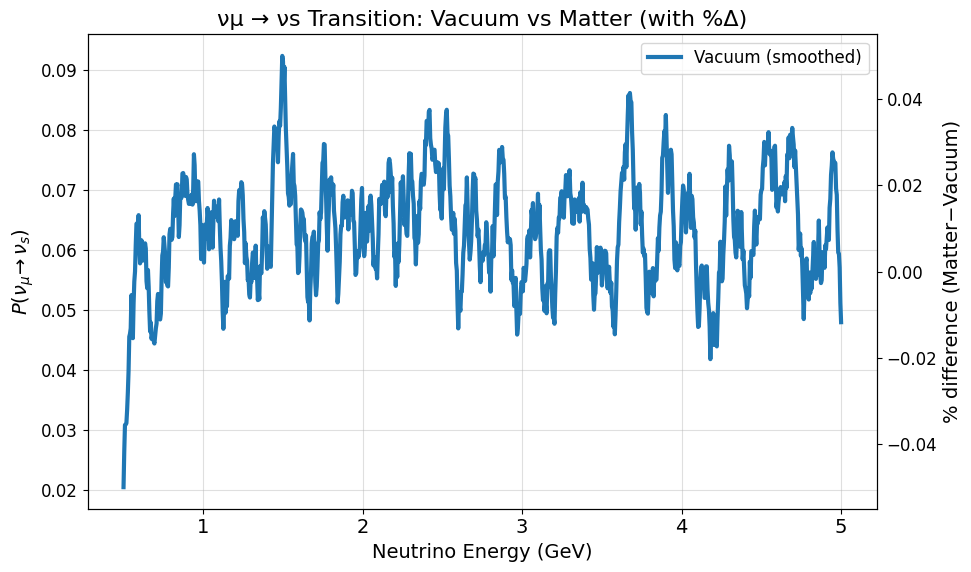

In [98]:
# energy grid
energies = np.linspace(0.5, 5.0, 1000)

# raw probabilities
pv = np.array([compute_transition_probability(E, L, delta_m41_sq,
                theta_14, theta_24, theta_34, matter=False)
               for E in energies])
pm = np.array([compute_transition_probability(E, L, delta_m41_sq,
                theta_14, theta_24, theta_34, matter=True)
               for E in energies])

# smooth with a little boxcar (window=21 points)
window = 21
kernel = np.ones(window) / window
pv_s = np.convolve(pv, kernel, mode='same')
pm_s = np.convolve(pm, kernel, mode='same')

# percent diff
pct = 100 * (pm_s - pv_s) / pv_s

fig, ax1 = plt.subplots(figsize=(10,6))

# 1) Vacuum curve (for legend)
h_vac, = ax1.plot(energies, pv_s,
                   color='tab:blue', lw=3,
                   label='Vacuum (smoothed)',
                   zorder=3)

# 2) Shaded envelope (no legend)
ax1.fill_between(energies, pv_s, pm_s,
                 where=pm_s>pv_s,
                 color='tab:red', alpha=0.2,
                 zorder=2)

ax1.set_xlabel("Neutrino Energy (GeV)", fontsize=14)
ax1.set_ylabel(r"$P(\nu_\mu\!\to\nu_s)$",        fontsize=14)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid(alpha=0.4)

# twin‑y axis for percent difference (no legend)
ax2 = ax1.twinx()
ax2.plot(energies, pct,
         '--', color='black', lw=2,
         zorder=4)
ax2.set_ylabel("% difference (Matter−Vacuum)", fontsize=14)
ax2.tick_params(axis='y', labelsize=12)

# only show the vacuum line in the legend
ax1.legend(handles=[h_vac], loc='upper right', fontsize=12)

plt.title("νμ → νs Transition: Vacuum vs Matter (with %Δ)", fontsize=16)
plt.tight_layout()
plt.show()